#### Постановка задачи:

- В данной работе нужно решить задачи векторизации и классификации текстов несколькими способами с помощью нейросетевых моделей и сравнить между собой.

Для выполнения задания нужно загрузить набор данных для задачи multi-label классификации текстов EURLex (только английскую часть) следующим кодом:

In [2]:
!pip install datasets > /dev/null 2>&1

In [3]:
from datasets import load_dataset

dataset = load_dataset("multi_eurlex", "en")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from datasets import load_dataset
from tqdm.auto import tqdm

from sklearn.pipeline import Pipeline
from joblib import parallel_backend

import torch
import torch.nn as nn
import torch.optim as optim

import time

from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(font_scale=1.4, style="whitegrid")
%config InlineBackend.figure_format='retina'

In [ ]:
print(dataset.shape)
dataset["train"][0]

{'train': (55000, 3), 'test': (5000, 3), 'validation': (5000, 3)}


{'celex_id': '32006D0213',
 'text': 'COMMISSION DECISION\nof 6 March 2006\nestablishing the classes of reaction-to-fire performance for certain construction products as regards wood flooring and solid wood panelling and cladding\n(notified under document number C(2006) 655)\n(Text with EEA relevance)\n(2006/213/EC)\nTHE COMMISSION OF THE EUROPEAN COMMUNITIES,\nHaving regard to the Treaty establishing the European Community,\nHaving regard to Directive 89/106/EEC of 21 December 1988, on the approximation of laws, regulations and administrative provisions of the Member States relating to construction products (1), and in particular Article 20(2) thereof,\nWhereas:\n(1)\nDirective 89/106/EEC envisages that in order to take account of different levels of protection for construction works at national, regional or local level, it may be necessary to establish in the interpretative documents classes corresponding to the performance of products in respect of each essential requirement. Those d

__Задание 1 (5 баллов):__ Самый простой способ выучить модель классификации - использовать лог-регрессию на сжатых плотных векторах документов. Для этого нужно выполнить ряд подзадач.

Преобразовать данные в векторный вид с помощью `CountVectorizer` и `TruncatedSVD`:

In [5]:
# your code here

X_train = [x["text"] for x in dataset["train"]]
X_valid = [x["text"] for x in dataset["validation"]]
X_test = [x["text"] for x in dataset["test"]]

Конвертировать метки классов в вид бинарной матрицы с размером "число объектов" на "число классов":

In [6]:
def set_labels(data):
    labels = []
    for item in data:
        label_vector = np.zeros(21)
        label_vector[item["labels"]] = 1
        labels.append(label_vector)
    return np.array(labels)

In [7]:
# your code here

y_train = set_labels(dataset["train"])
y_valid = set_labels(dataset["validation"])
y_test = set_labels(dataset["test"])

In [ ]:
print(y_train[0])

[1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [ ]:
print((X_train[0]))

COMMISSION DECISION
of 6 March 2006
establishing the classes of reaction-to-fire performance for certain construction products as regards wood flooring and solid wood panelling and cladding
(notified under document number C(2006) 655)
(Text with EEA relevance)
(2006/213/EC)
THE COMMISSION OF THE EUROPEAN COMMUNITIES,
Having regard to the Treaty establishing the European Community,
Having regard to Directive 89/106/EEC of 21 December 1988, on the approximation of laws, regulations and administrative provisions of the Member States relating to construction products (1), and in particular Article 20(2) thereof,
Whereas:
(1)
Directive 89/106/EEC envisages that in order to take account of different levels of protection for construction works at national, regional or local level, it may be necessary to establish in the interpretative documents classes corresponding to the performance of products in respect of each essential requirement. Those documents have been published as the ‘Communicati

Обучить мета-модель на основе лог-регрессии с помощью `MultiOutputClassifier`:

In [ ]:
logreg_params = {"max_iter": 1000, "solver": "sag", "n_jobs": -1, "tol": 1e-3}

vectorizer = CountVectorizer(max_features=100)
vectorizer.fit(X_train)

X_train_counts = vectorizer.fit_transform(X_train)

svd = TruncatedSVD(n_components=20)
X_train_svd = svd.fit_transform(X_train_counts)

X_valid_counts = vectorizer.transform(X_valid)
X_valid_svd = svd.transform(X_valid_counts)

X_test_counts = vectorizer.transform(X_test)
X_test_svd = svd.transform(X_test_counts)


model = MultiOutputClassifier(LogisticRegression(**logreg_params))
model.fit(X_train_svd, y_train)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000, n_jobs=-1,
                                                   solver='sag', tol=0.001))

Описать функцию подбора оптимальных порогов бинаризации для каждого класса и подобрать их для модели на валидационной выборке:

In [37]:
def calculate_best_thresholds(model, X_valid, y_valid, average="macro", step=0.1):
    best_thresholds = []
    y_valid_proba = model.predict_proba(X_valid)

    for i in range(y_valid.shape[1]):
        best_score = -1
        best_threshold = 0
        for threshold in np.arange(0, 1, step):
            preds = (y_valid_proba[i][:, 1] >= threshold).astype(int)
            score = f1_score(y_valid[:, i], preds, average=average)
            if score > best_score:
                best_score = score
                best_threshold = threshold
        best_thresholds.append(best_threshold)

    return best_thresholds

Описать код применения модели и порогов к выходным вероятностям для получения значений F1-меры с micro и macro усреднениями и вычислить их на тестовой выборке. Для получения максимального балла код этого подзадания должен быть написан в векторном виде с помощью NumPy, без циклов:

In [ ]:
thresholds = calculate_best_thresholds(model, X_test_svd, y_test)

y_test_proba = model.predict_proba(X_test_svd)
y_test_pred = np.array(
    [
        (y_test_proba[i][:, 1] >= thresholds[i]).astype(int)
        for i in range(len(thresholds))
    ]
).T

print(f"F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.2f}")
print(f"F1-micro: {f1_score(y_test, y_test_pred, average='micro'):.2f}")

F1-macro: 0.27
F1-micro: 0.47


Провести набор запусков с различными комбинациями размера словаря `CountVectorizer` и числа компонент в `TruncatedSVD` и оценить их влияние на качество на текстовой выборке

- попробовать нужно как минимум 3 существенно различных значения для каждого параметра
- результаты должны быть представлены наглядно в виде таблиц и сделанных на их основе выводов

In [ ]:
logreg_params = {"max_iter": 1000, "solver": "sag", "n_jobs": -1, "tol": 1e-3}

for vocab_size in [100, 200, 300]:
    vectorizer = CountVectorizer(max_features=vocab_size)
    vectorizer.fit(X_train)

    X_train_counts = vectorizer.fit_transform(X_train)
    X_valid_counts = vectorizer.transform(X_valid)
    X_test_counts = vectorizer.transform(X_test)

    for svd_comp in [20, 30, 40]:
        svd = TruncatedSVD(n_components=svd_comp)
        X_train_svd = svd.fit_transform(X_train_counts)
        X_valid_svd = svd.transform(X_valid_counts)
        X_test_svd = svd.transform(X_test_counts)

        model = MultiOutputClassifier(LogisticRegression(**logreg_params), n_jobs=-1)
        model.fit(X_train_svd, y_train)

        thresholds = calculate_best_thresholds(model, X_test_svd, y_test)

        y_test_proba = model.predict_proba(X_test_svd)
        y_test_pred = np.array(
            [
                (y_test_proba[i][:, 1] >= thresholds[i]).astype(int)
                for i in range(len(thresholds))
            ]
        ).T

        print(
            f"F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.2f} with svd_comp={svd_comp}, vocab_size={vocab_size}"
        )
        print(
            f"F1-micro: {f1_score(y_test, y_test_pred, average='micro'):.2f} with svd_comp={svd_comp}, vocab_size={vocab_size}"
        )

F1-macro: 0.27 with svd_comp=20, vocab_size=100
F1-micro: 0.47 with svd_comp=20, vocab_size=100
F1-macro: 0.29 with svd_comp=30, vocab_size=100
F1-micro: 0.50 with svd_comp=30, vocab_size=100
F1-macro: 0.27 with svd_comp=40, vocab_size=100
F1-micro: 0.47 with svd_comp=40, vocab_size=100
F1-macro: 0.28 with svd_comp=20, vocab_size=200
F1-micro: 0.49 with svd_comp=20, vocab_size=200
F1-macro: 0.29 with svd_comp=30, vocab_size=200
F1-micro: 0.50 with svd_comp=30, vocab_size=200
F1-macro: 0.29 with svd_comp=40, vocab_size=200
F1-micro: 0.48 with svd_comp=40, vocab_size=200
F1-macro: 0.28 with svd_comp=20, vocab_size=300
F1-micro: 0.50 with svd_comp=20, vocab_size=300
F1-macro: 0.30 with svd_comp=30, vocab_size=300
F1-micro: 0.51 with svd_comp=30, vocab_size=300
F1-macro: 0.30 with svd_comp=40, vocab_size=300
F1-micro: 0.49 with svd_comp=40, vocab_size=300


лучшие параметры как видно svd_comp=30 и vocab_size=300, так как они дают максимальные значения F1-macro (0.30) и F1-micro (0.51). Также можно сказать, что увеличение параметров ведет к росту показателей, но после svd_comp=30 прирост незначителен. F1-micro стабильно растёт, а F1-macro меняется незначительно, что может указывать на дисбаланс классов

__Задание 2 (5 баллов):__ Заменить метод векторизации документов для модели выше на BERT.

Описать код класса BERTVectorizer, который должен уметь обрабатывать данные в батчевом режиме на заданном устройстве. Должно быть предусмотрено 2 режима формирования векторов документов - на основе CLS-токена и на основе усреднения всех выходных векторов (тут нужно использовать поле `attention_mask` и игнорировать векторы токенов паддинга, для которых в маске записан 0):

In [ ]:
class BERTVectorizer:
    def __init__(self, model_name, batch_size=100, device="cuda:0"):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(device)
        self.batch_size = batch_size
        self.device = device

    def __call__(self, texts, averaging="cls"):
        embeddings = []
        for i in tqdm(range(0, len(texts), self.batch_size)):
            batch = texts[i : i + self.batch_size]
            embeddings.append(self._vectorize_batch(batch, averaging))
        return np.vstack(embeddings)

    def _vectorize_batch(self, texts, averaging):
        inputs = self.tokenizer(
            texts, padding=True, truncation=True, return_tensors="pt", max_length=512
        ).to(self.device)

        with torch.no_grad():
            out = self.model(**inputs)

        if averaging == "cls":
            batch_embeddings = out.last_hidden_state[:, 0, :].cpu().numpy()
        else:
            attention_mask = inputs["attention_mask"].unsqueeze(-1).cpu()
            last_hidden = out.last_hidden_state.cpu()
            batch_embeddings = (last_hidden * attention_mask).sum(
                1
            ) / attention_mask.sum(1)
            batch_embeddings = batch_embeddings.numpy()

        return batch_embeddings

In [ ]:
vectorizer = BERTVectorizer("cointegrated/rubert-tiny2")

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/118M [00:00<?, ?B/s]

Использовать его для векторизации данных с помощью модели `cointegrated/rubert-tiny2`:

In [ ]:
X_train_BERT_vec = vectorizer(X_train, averaging="mean")
X_valid_BERT_vec = vectorizer(X_valid, averaging="mean")
X_test_BERT_vec = vectorizer(X_test, averaging="mean")

  0%|          | 0/550 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# your code here
model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train_BERT_vec, y_train)

thresholds = calculate_best_thresholds(model, X_valid_BERT_vec, y_valid)

y_test_proba = model.predict_proba(X_test_BERT_vec)
y_test_pred = np.array(
    [
        (y_test_proba[i][:, 1] >= thresholds[i]).astype(int)
        for i in range(len(thresholds))
    ]
).T

print(f"F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.2f}")
print(f"F1-micro: {f1_score(y_test, y_test_pred, average='micro'):.2f}")

F1-macro: 0.54
F1-micro: 0.68


In [ ]:
X_train_BERT_vec = vectorizer(X_train)
X_valid_BERT_vec = vectorizer(X_valid)
X_test_BERT_vec = vectorizer(X_test)

  0%|          | 0/550 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# your code here
model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train_BERT_vec, y_train)

thresholds = calculate_best_thresholds(model, X_valid_BERT_vec, y_valid)

y_test_proba = model.predict_proba(X_test_BERT_vec)
y_test_pred = np.array(
    [
        (y_test_proba[i][:, 1] >= thresholds[i]).astype(int)
        for i in range(len(thresholds))
    ]
).T

print(f"F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.2f}")
print(f"F1-micro: {f1_score(y_test, y_test_pred, average='micro'):.2f}")

F1-macro: 0.56
F1-micro: 0.66


Описать код сохранения/загрузки векторов с диска:

In [ ]:
# your code here
np.save("X_train_bert.npy", X_train_BERT_vec)
np.save("X_valid_bert.npy", X_valid_BERT_vec)
np.save("X_test_bert.npy", X_test_BERT_vec)

"""
X_train_BERT_vec = np.load('X_train_bert.npy')
X_valid_BERT_vec = np.load('X_valid_bert.npy')
X_test_BERT_vec = np.load('X_test_bert.npy')
"""

"\nX_train_BERT_vec = np.load('X_train_bert.npy')\nX_valid_BERT_vec = np.load('X_valid_bert.npy')\nX_test_BERT_vec = np.load('X_test_bert.npy')\n"

Повторить обучение модели и замер качества из п.1 на новых векторах:

In [ ]:
vectorizer_large = BERTVectorizer(
    "sentence-transformers/paraphrase-xlm-r-multilingual-v1"
)

tokenizer_config.json:   0%|          | 0.00/550 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

In [ ]:
X_train_BERT_large_vec = vectorizer_large(X_train, averaging="mean")
X_valid_BERT_large_vec = vectorizer_large(X_valid, averaging="mean")
X_test_BERT_large_vec = vectorizer_large(X_test, averaging="mean")

  0%|          | 0/550 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
# your code here
model = MultiOutputClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train_BERT_large_vec, y_train)

In [ ]:
thresholds = calculate_best_thresholds(model, X_valid_BERT_large_vec, y_valid)

y_test_proba = model.predict_proba(X_test_BERT_large_vec)
y_test_pred = np.array(
    [
        (y_test_proba[i][:, 1] >= thresholds[i]).astype(int)
        for i in range(len(thresholds))
    ]
).T

print(f"F1-macro: {f1_score(y_test, y_test_pred, average='macro'):.2f}")
print(f"F1-micro: {f1_score(y_test, y_test_pred, average='micro'):.2f}")

F1-macro: 0.60
F1-micro: 0.72


In [ ]:
# your code here
np.save("X_train_bert_large.npy", X_train_BERT_vec)
np.save("X_valid_bert_large.npy", X_valid_BERT_vec)
np.save("X_test_bert_large.npy", X_test_BERT_vec)

"""
X_train_BERT_vec = np.load('X_train_bert_large.npy')
X_valid_BERT_vec = np.load('X_valid_bert_large.npy')
X_test_BERT_vec = np.load('X_test_bert_large.npy')
"""

Попробовать заменить векторизатор на более крупный и качественный (например, `intfloat/multilingual-e5-base` или `sentence-transformers/paraphrase-xlm-r-multilingual-v1`) и повторить обучение, сделать выводы о качестве:

как мы видим значания метрик увеличились, но за этот прирост пришлось обрабатывать данные значительно дольше. Также кажется, что прирост не очень большой возможно следовало бы использовать другую модель для классификации

In [ ]:
# your code here

__Задание 3 (5 баллов):__ Реализовать модель, похожую на реализованную в п.1, на PyTorch.

Описать класс модели с одним линейным слоем, в качестве активации на выходе опробовать сигмоиду:

In [38]:
vectorizer = CountVectorizer(max_features=10000)
X_train_counts = vectorizer.fit_transform(X_train)
X_valid_counts = vectorizer.transform(X_valid)
X_test_counts = vectorizer.transform(X_test)

svd = TruncatedSVD(n_components=300)
X_train_vec = svd.fit_transform(X_train_counts)
X_valid_vec = svd.transform(X_valid_counts)
X_test_vec = svd.transform(X_test_counts)

In [39]:
class Model(nn.Module):
    def __init__(self, embedding_dim, num_labels):
        super().__init__()
        self.linear = nn.Linear(embedding_dim, num_labels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.linear(x)
        return self.sigmoid(x)

Получить с помощью кода из п.1 векторные представления данных:

In [40]:
class TextDataset(Dataset):
    def __init__(self, X, y):
        super().__init__()
        self.X = torch.FloatTensor(X.astype(np.float32))
        self.y = torch.FloatTensor(y.astype(np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Описать код класса датасета, объявить датасеты и загрузчики данных с подходящими размерами батчей:

In [41]:
# your code here

train_dataset = TextDataset(X_train_vec, y_train)
valid_dataset = TextDataset(X_valid_vec, y_valid)
test_dataset = TextDataset(X_test_vec, y_test)

batch_size = 256
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

Создать модель, оптимизатор и функцией потерь binary cross-entropy:

In [50]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(X_train_vec.shape[1], y_train.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

- Описать цикл обучения, на каждом шаге считать лосс на валидационном датасете
- Раз в несколько шагов подбирать на валидации оптимальные пороги бинаризации и делать на нём же замер F1-меры с micro/macro усреднениями
- Запустить обучение с необходимым числом эпох с замером времени выполнения эпохи
- Для лучшей модели в конце обучения повторно подобрать пороги на валидации и произвести итоговый замер на тестовых данных
- Вывести графики убывания лосса на обучении и валидации и значений метрик

In [43]:
def metrics(model, dataloader, device):
    model.eval()
    y_true = []
    y_pred = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            y_true.append(y.cpu().numpy())
            y_pred.append(out.cpu().numpy())

    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)

    thresholds = []
    for i in range(y_true.shape[1]):
        best_score = -1
        best_threshold = 0
        for threshold in np.arange(0, 1, 0.1):
            preds = (y_pred[:, i] >= threshold).astype(int)
            score = f1_score(y_true[:, i], preds, average="macro")
            if score > best_score:
                best_score = score
                best_threshold = threshold
        thresholds.append(best_threshold)

    final_pred = np.zeros_like(y_pred)
    for i, threshold in enumerate(thresholds):
        final_pred[:, i] = (y_pred[:, i] >= threshold).astype(int)

    f1_macro = f1_score(y_true, final_pred, average="macro")
    f1_micro = f1_score(y_true, final_pred, average="micro")

    return f1_macro, f1_micro

In [51]:
def exper(num_epochs, model, train_dataloader, valid_dataloader, test_dataloader):
    train_loss_list, valid_loss_list = [], []
    test_f1_micro_list, test_f1_macro_list = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0
        timestamp_start = time.time()

        for X, y in train_dataloader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * X.size(0)

        train_loss = epoch_loss / len(train_dataset)
        train_loss_list.append(train_loss)

        model.eval()
        valid_loss = 0
        y_true = []
        y_pred = []
        with torch.no_grad():
            for X, y in valid_dataloader:
                X, y = X.to(device), y.to(device)
                out = model(X)
                loss = criterion(out, y)
                valid_loss += loss.item() * X.size(0)
                y_true.append(y.cpu().numpy())
                y_pred.append(out.cpu().numpy())

        y_true = np.vstack(y_true)
        y_pred = np.vstack(y_pred)

        thresholds = []
        for i in range(y_true.shape[1]):
            best_score = -1
            best_threshold = 0
            for threshold in np.arange(0, 1, 0.1):
                preds = (y_pred[:, i] >= threshold).astype(int)
                score = f1_score(y_true[:, i], preds, average="macro")
                if score > best_score:
                    best_score = score
                    best_threshold = threshold
            thresholds.append(best_threshold)

        final_pred = np.zeros_like(y_pred)
        for i, threshold in enumerate(thresholds):
            final_pred[:, i] = (y_pred[:, i] >= threshold).astype(int)

        f1_macro = f1_score(y_true, final_pred, average="macro")
        f1_micro = f1_score(y_true, final_pred, average="micro")

        valid_loss = valid_loss / len(valid_dataset)
        valid_loss_list.append(valid_loss)

        test_f1_macro_list.append(f1_macro)
        test_f1_micro_list.append(f1_micro)

        print(
            f"epoch {epoch} "
            f"time {round(time.time() - timestamp_start)}s "
            f"train loss: {train_loss_list[-1]:.4f} "
            f"valid loss: {valid_loss_list[-1]:.4f} "
            f"valid F1-micro: {f1_micro:.2f} "
            f"valid F1-macro: {f1_macro:.2f}"
        )
    final_f1_macro, final_f1_micro = metrics(model, test_dataloader, device)
    print("test f1-macro ", final_f1_macro, "test f1-micro ", final_f1_micro)

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)

    plt.title("loss curve")

    plt.plot(train_loss_list, label="train loss")
    plt.plot(valid_loss_list, label="talidation loss")

    plt.xlabel("epoch")
    plt.ylabel("loss")

    plt.legend(fontsize=12)

    plt.subplot(1, 2, 2)
    plt.title("F1 score")

    plt.plot(test_f1_macro_list, label="macro")
    plt.plot(test_f1_micro_list, label="micro")

    plt.xlabel("epoch")
    plt.ylabel("F1 score")

    plt.legend(fontsize=12)
    plt.show()

epoch 0 time 2s train loss: 0.7750 valid loss: 0.3457 valid F1-micro: 0.67 valid F1-macro: 0.51
epoch 1 time 1s train loss: 0.2629 valid loss: 0.3176 valid F1-micro: 0.70 valid F1-macro: 0.55
epoch 2 time 1s train loss: 0.2473 valid loss: 0.3154 valid F1-micro: 0.72 valid F1-macro: 0.57
epoch 3 time 1s train loss: 0.2406 valid loss: 0.3102 valid F1-micro: 0.71 valid F1-macro: 0.57
epoch 4 time 1s train loss: 0.2382 valid loss: 0.3175 valid F1-micro: 0.72 valid F1-macro: 0.58
epoch 5 time 1s train loss: 0.2370 valid loss: 0.3147 valid F1-micro: 0.72 valid F1-macro: 0.58
epoch 6 time 1s train loss: 0.2369 valid loss: 0.3154 valid F1-micro: 0.72 valid F1-macro: 0.59
epoch 7 time 2s train loss: 0.2364 valid loss: 0.3195 valid F1-micro: 0.71 valid F1-macro: 0.58
epoch 8 time 1s train loss: 0.2360 valid loss: 0.3155 valid F1-micro: 0.72 valid F1-macro: 0.59
epoch 9 time 1s train loss: 0.2357 valid loss: 0.3215 valid F1-micro: 0.73 valid F1-macro: 0.59
epoch 10 time 1s train loss: 0.2362 vali

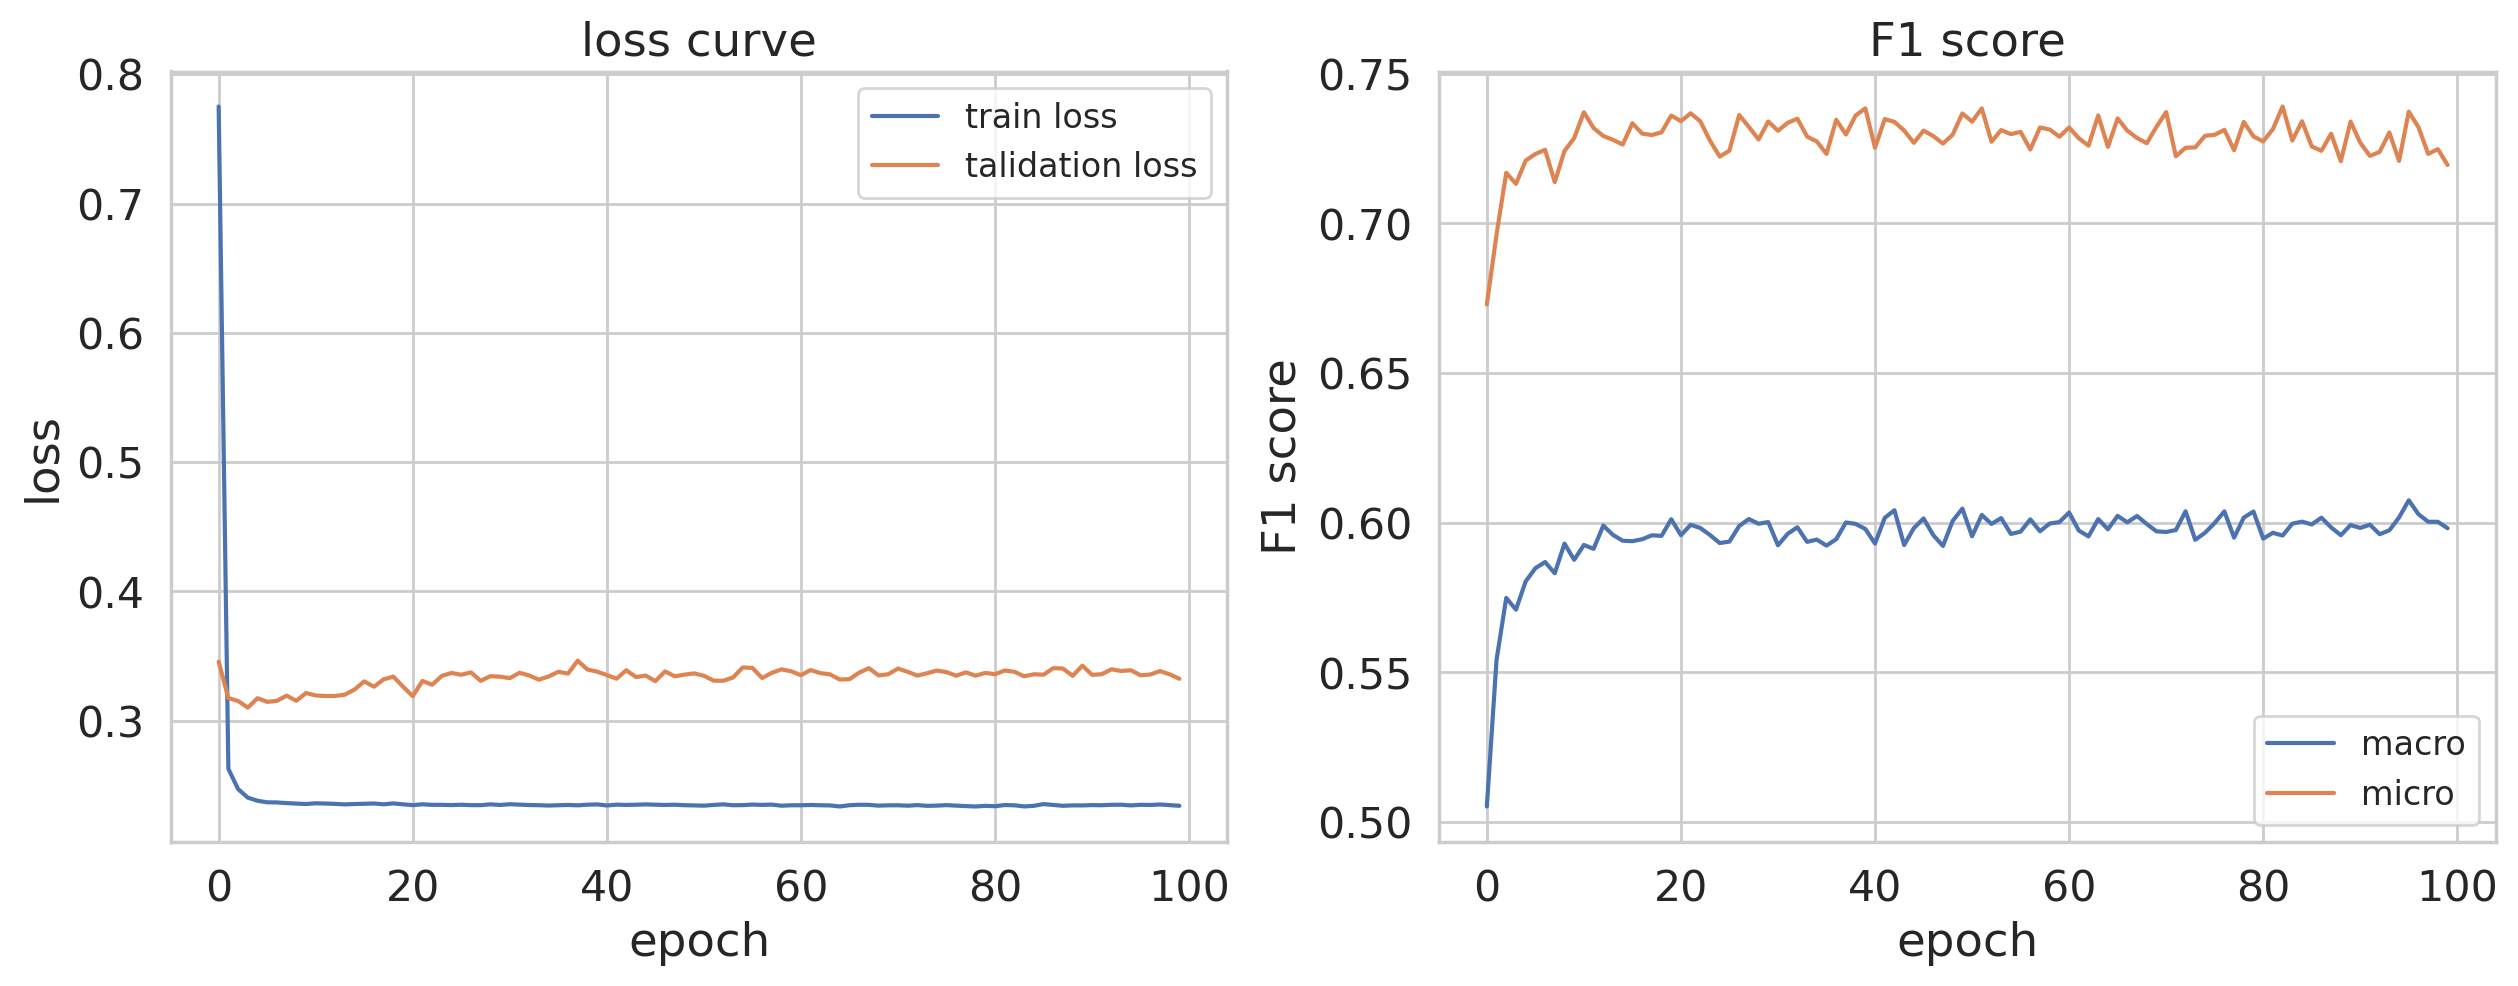

In [52]:
exper(100, model, train_dataloader, valid_dataloader, test_dataloader)

Заменить активацию на Softmax, а функцию потерь на кросс-энтропию, переобучить модель при тех же условиях, измерить качество и сделать выводы о причинах его изменения:

In [22]:
class ModelWithSoftMax(nn.Module):
    def __init__(self, embedding_dim, num_labels):
        super().__init__()
        self.linear = nn.Linear(embedding_dim, num_labels)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        x = self.linear(x)
        return self.softmax(x)

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ModelWithSoftMax(X_train_vec.shape[1], y_train.shape[1]).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

epoch 0 time 1s train loss: 9.3285 valid loss: 10.5950 valid F1-micro: 0.50 valid F1-macro: 0.18
epoch 1 time 1s train loss: 9.2128 valid loss: 10.5724 valid F1-micro: 0.50 valid F1-macro: 0.18
epoch 2 time 1s train loss: 9.1989 valid loss: 10.5622 valid F1-micro: 0.50 valid F1-macro: 0.18
epoch 3 time 1s train loss: 9.1921 valid loss: 10.5572 valid F1-micro: 0.51 valid F1-macro: 0.19
epoch 4 time 1s train loss: 9.1879 valid loss: 10.5533 valid F1-micro: 0.50 valid F1-macro: 0.18
epoch 5 time 1s train loss: 9.1847 valid loss: 10.5527 valid F1-micro: 0.50 valid F1-macro: 0.18
epoch 6 time 1s train loss: 9.1822 valid loss: 10.5484 valid F1-micro: 0.51 valid F1-macro: 0.19
epoch 7 time 1s train loss: 9.1799 valid loss: 10.5454 valid F1-micro: 0.52 valid F1-macro: 0.20
epoch 8 time 1s train loss: 9.1783 valid loss: 10.5453 valid F1-micro: 0.52 valid F1-macro: 0.20
epoch 9 time 2s train loss: 9.1758 valid loss: 10.5415 valid F1-micro: 0.52 valid F1-macro: 0.20
epoch 10 time 1s train loss: 9

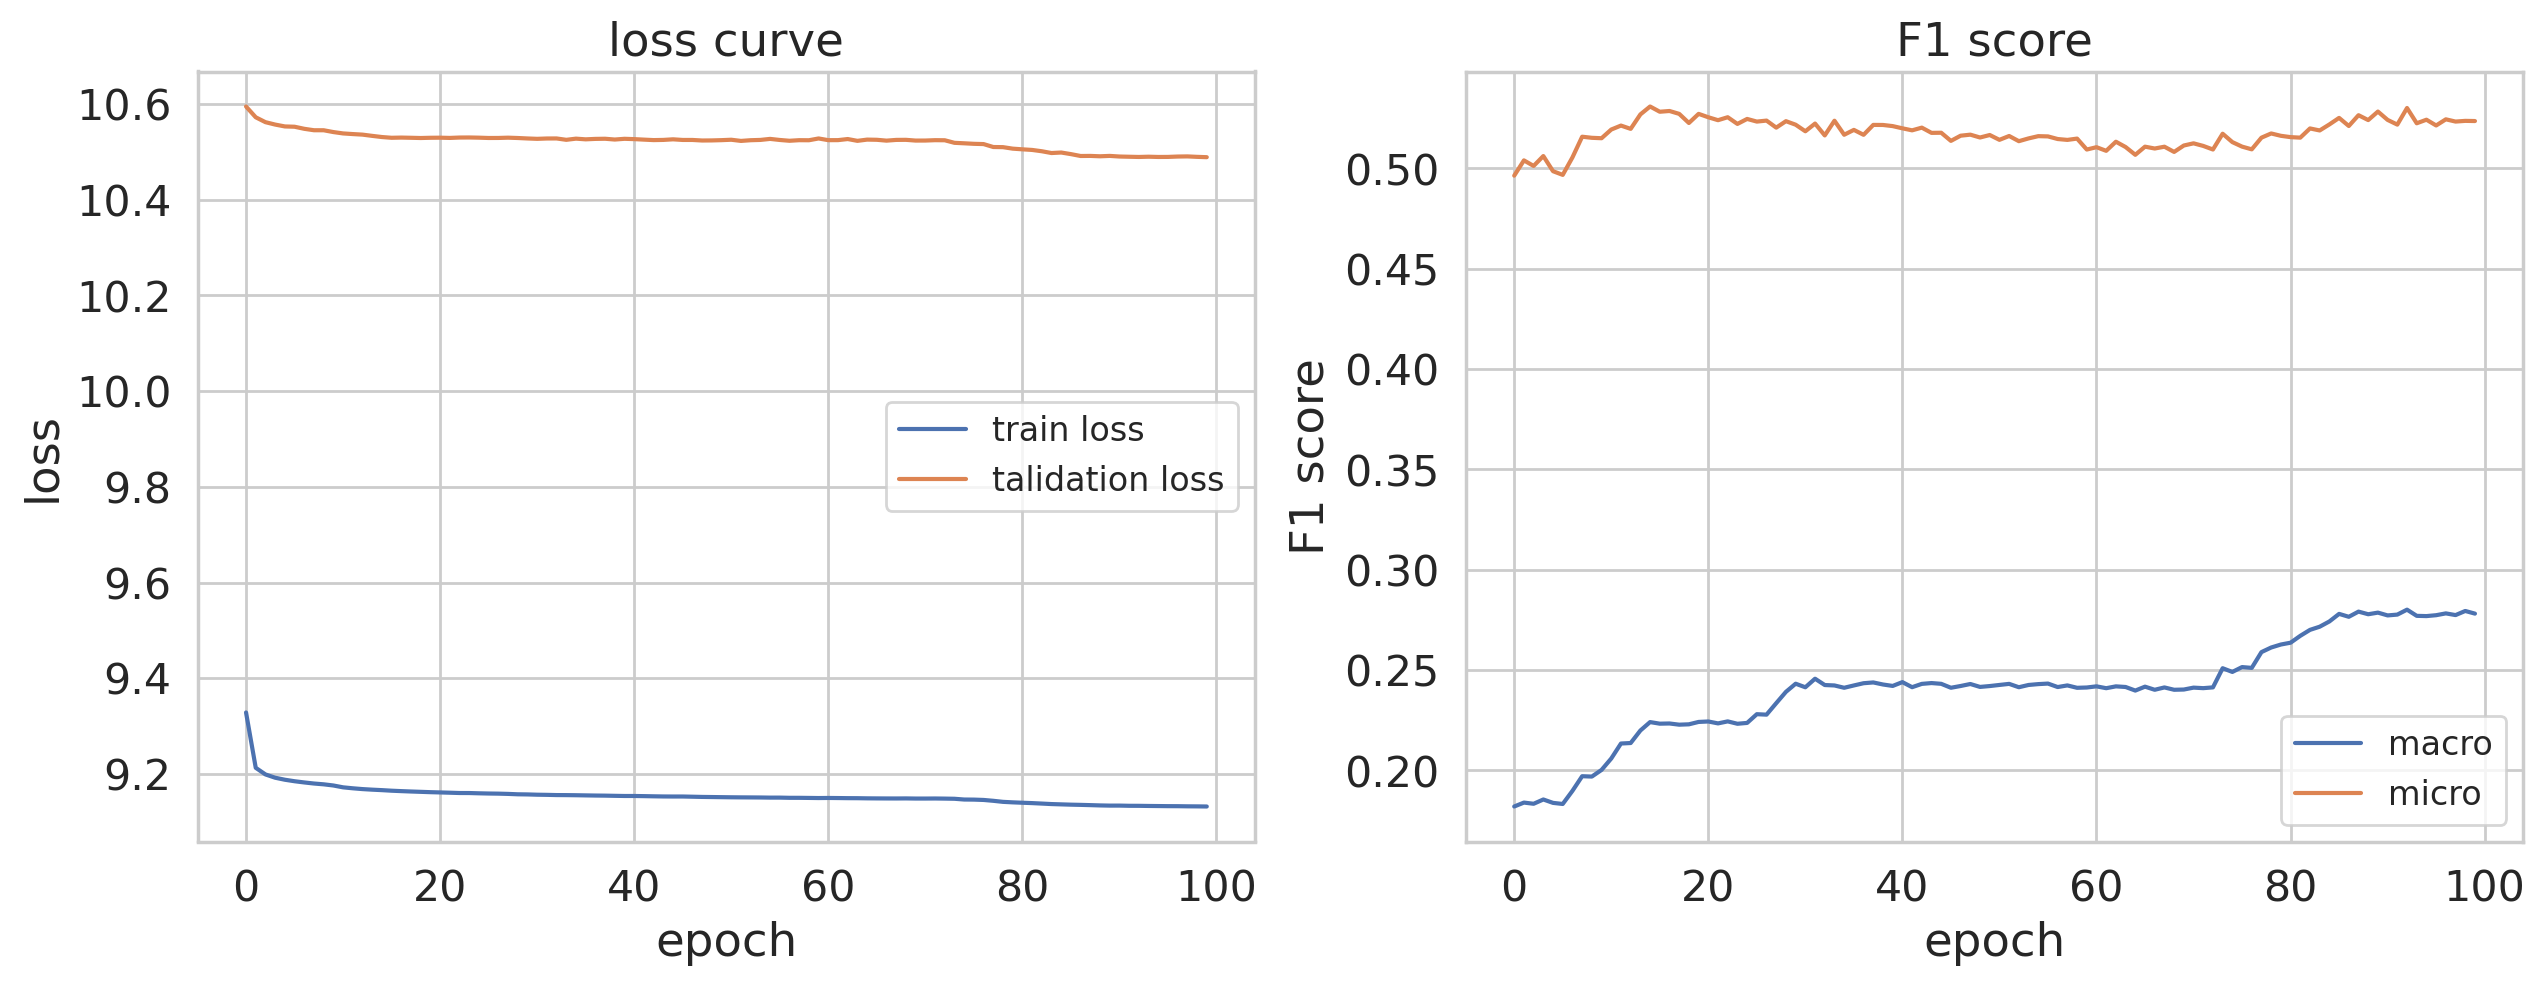

In [24]:
exper(100, model, train_dataloader, valid_dataloader, test_dataloader)

как видно показатели довольно низкие. Это связано с тем что испольщование кроссэнтропии и софтмакс априорно подразумевает взаимоисключение классов. Это не подходит для multi label классификации

__Задание 4 (5 баллов):__ Провести ряд экспериментов по улучшению качества работы модели, попробовать следующие идеи:

- варьирование числа и размера линейных слоёв
- использование различных функций активации между слоями
- выбор другого оптимизатора, варьирование его важных гиперпараметров
- замена векторизатора на BERT

Эксперименты должны быть подкреплены понятными графиками, таблицами, пояснениями причин такого выбора гиперпараметров и выводов на основе проделанной работы. Балл за задание определяется по четырём критериям:

- адекватность и полнота экспериментов
- качество отчета и выводов
- итоговое значение качества работы модели на тестовой выборке
- скорость сходимости лосса к целевому значению

In [25]:
class TestModel(nn.Module):
    def __init__(
        self, embedding_dim, num_labels, hidden_dims=[512, 256], activation="ReLU"
    ):
        super().__init__()

        layers = []
        input_dim = embedding_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            if activation == "ReLU":
                layers.append(nn.ReLU())
            elif activation == "LeakyReLU":
                layers.append(nn.LeakyReLU())
            elif activation == "Tanh":
                layers.append(nn.Tanh())
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, num_labels))
        layers.append(nn.Sigmoid())

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

Using {'hidden_dims': [512], 'activation': 'ReLU'}
epoch 0 time 3s train loss: 0.2830 valid loss: 0.2510 valid F1-micro: 0.74 valid F1-macro: 0.60
epoch 1 time 2s train loss: 0.1906 valid loss: 0.2322 valid F1-micro: 0.76 valid F1-macro: 0.62
epoch 2 time 2s train loss: 0.1714 valid loss: 0.2306 valid F1-micro: 0.77 valid F1-macro: 0.63
epoch 3 time 2s train loss: 0.1589 valid loss: 0.2205 valid F1-micro: 0.77 valid F1-macro: 0.64
epoch 4 time 2s train loss: 0.1499 valid loss: 0.2223 valid F1-micro: 0.77 valid F1-macro: 0.64
epoch 5 time 1s train loss: 0.1429 valid loss: 0.2212 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 6 time 1s train loss: 0.1370 valid loss: 0.2176 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 7 time 1s train loss: 0.1316 valid loss: 0.2256 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 8 time 1s train loss: 0.1273 valid loss: 0.2244 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 9 time 1s train loss: 0.1240 valid loss: 0.2301 valid F1-micro: 0.78 valid F1-m

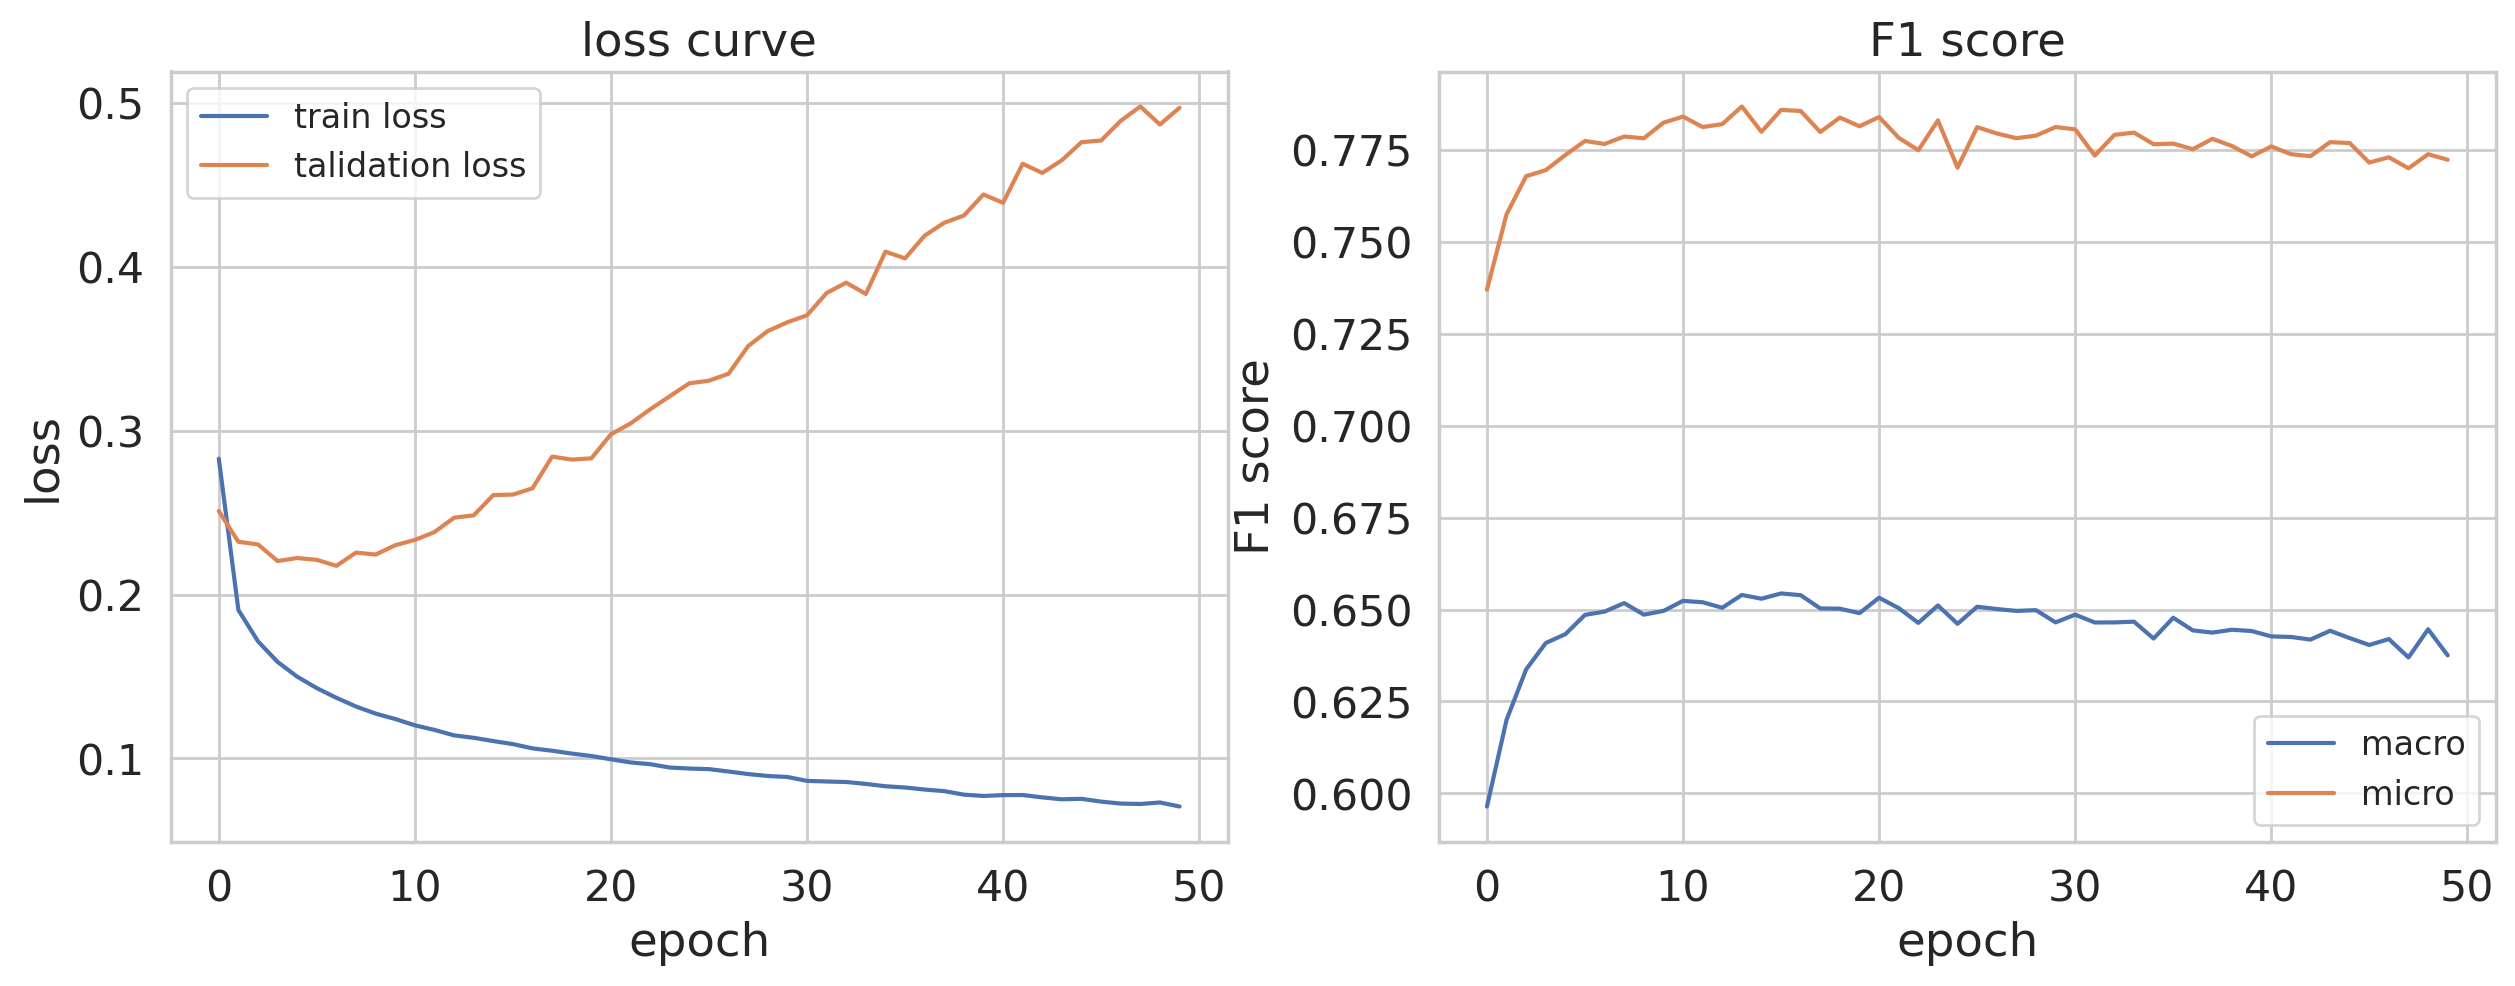

Using {'hidden_dims': [512, 256], 'activation': 'ReLU'}
epoch 0 time 1s train loss: 0.2441 valid loss: 0.2258 valid F1-micro: 0.75 valid F1-macro: 0.59
epoch 1 time 1s train loss: 0.1716 valid loss: 0.2065 valid F1-micro: 0.77 valid F1-macro: 0.63
epoch 2 time 1s train loss: 0.1538 valid loss: 0.2013 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 3 time 1s train loss: 0.1431 valid loss: 0.2021 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 4 time 1s train loss: 0.1352 valid loss: 0.2007 valid F1-micro: 0.78 valid F1-macro: 0.66
epoch 5 time 2s train loss: 0.1278 valid loss: 0.2024 valid F1-micro: 0.79 valid F1-macro: 0.66
epoch 6 time 1s train loss: 0.1225 valid loss: 0.2060 valid F1-micro: 0.78 valid F1-macro: 0.66
epoch 7 time 1s train loss: 0.1171 valid loss: 0.2144 valid F1-micro: 0.78 valid F1-macro: 0.66
epoch 8 time 1s train loss: 0.1124 valid loss: 0.2143 valid F1-micro: 0.78 valid F1-macro: 0.66
epoch 9 time 1s train loss: 0.1080 valid loss: 0.2190 valid F1-micro: 0.79 valid

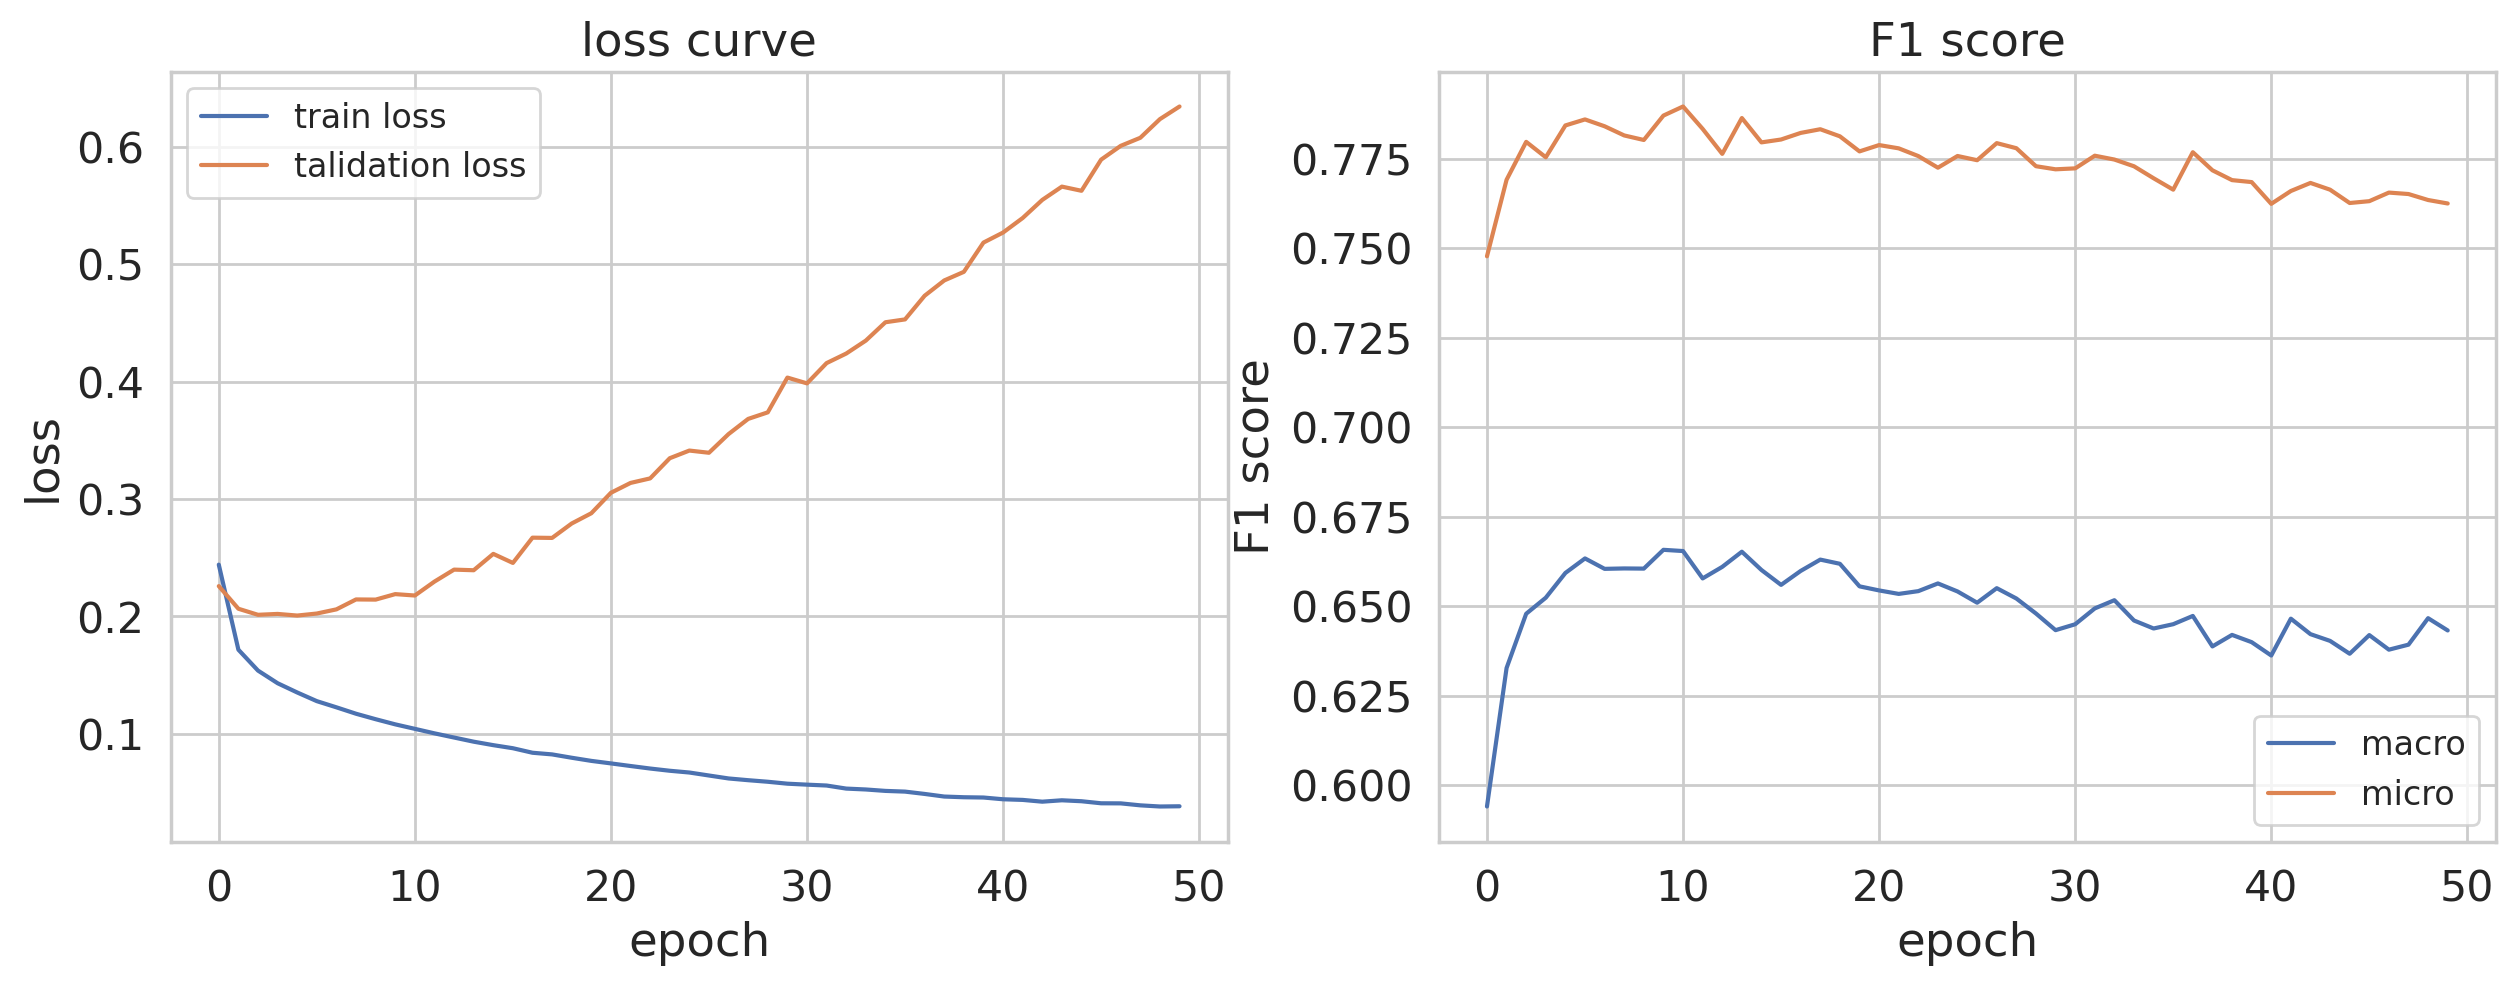

Using {'hidden_dims': [1024, 512, 256], 'activation': 'LeakyReLU'}
epoch 0 time 2s train loss: 0.2429 valid loss: 0.2234 valid F1-micro: 0.74 valid F1-macro: 0.60
epoch 1 time 2s train loss: 0.1652 valid loss: 0.2016 valid F1-micro: 0.77 valid F1-macro: 0.63
epoch 2 time 1s train loss: 0.1458 valid loss: 0.1971 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 3 time 1s train loss: 0.1333 valid loss: 0.1971 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 4 time 1s train loss: 0.1229 valid loss: 0.1935 valid F1-micro: 0.80 valid F1-macro: 0.67
epoch 5 time 1s train loss: 0.1136 valid loss: 0.1994 valid F1-micro: 0.80 valid F1-macro: 0.67
epoch 6 time 1s train loss: 0.1055 valid loss: 0.2012 valid F1-micro: 0.79 valid F1-macro: 0.67
epoch 7 time 1s train loss: 0.0974 valid loss: 0.2139 valid F1-micro: 0.80 valid F1-macro: 0.67
epoch 8 time 1s train loss: 0.0904 valid loss: 0.2246 valid F1-micro: 0.79 valid F1-macro: 0.66
epoch 9 time 2s train loss: 0.0842 valid loss: 0.2352 valid F1-micro:

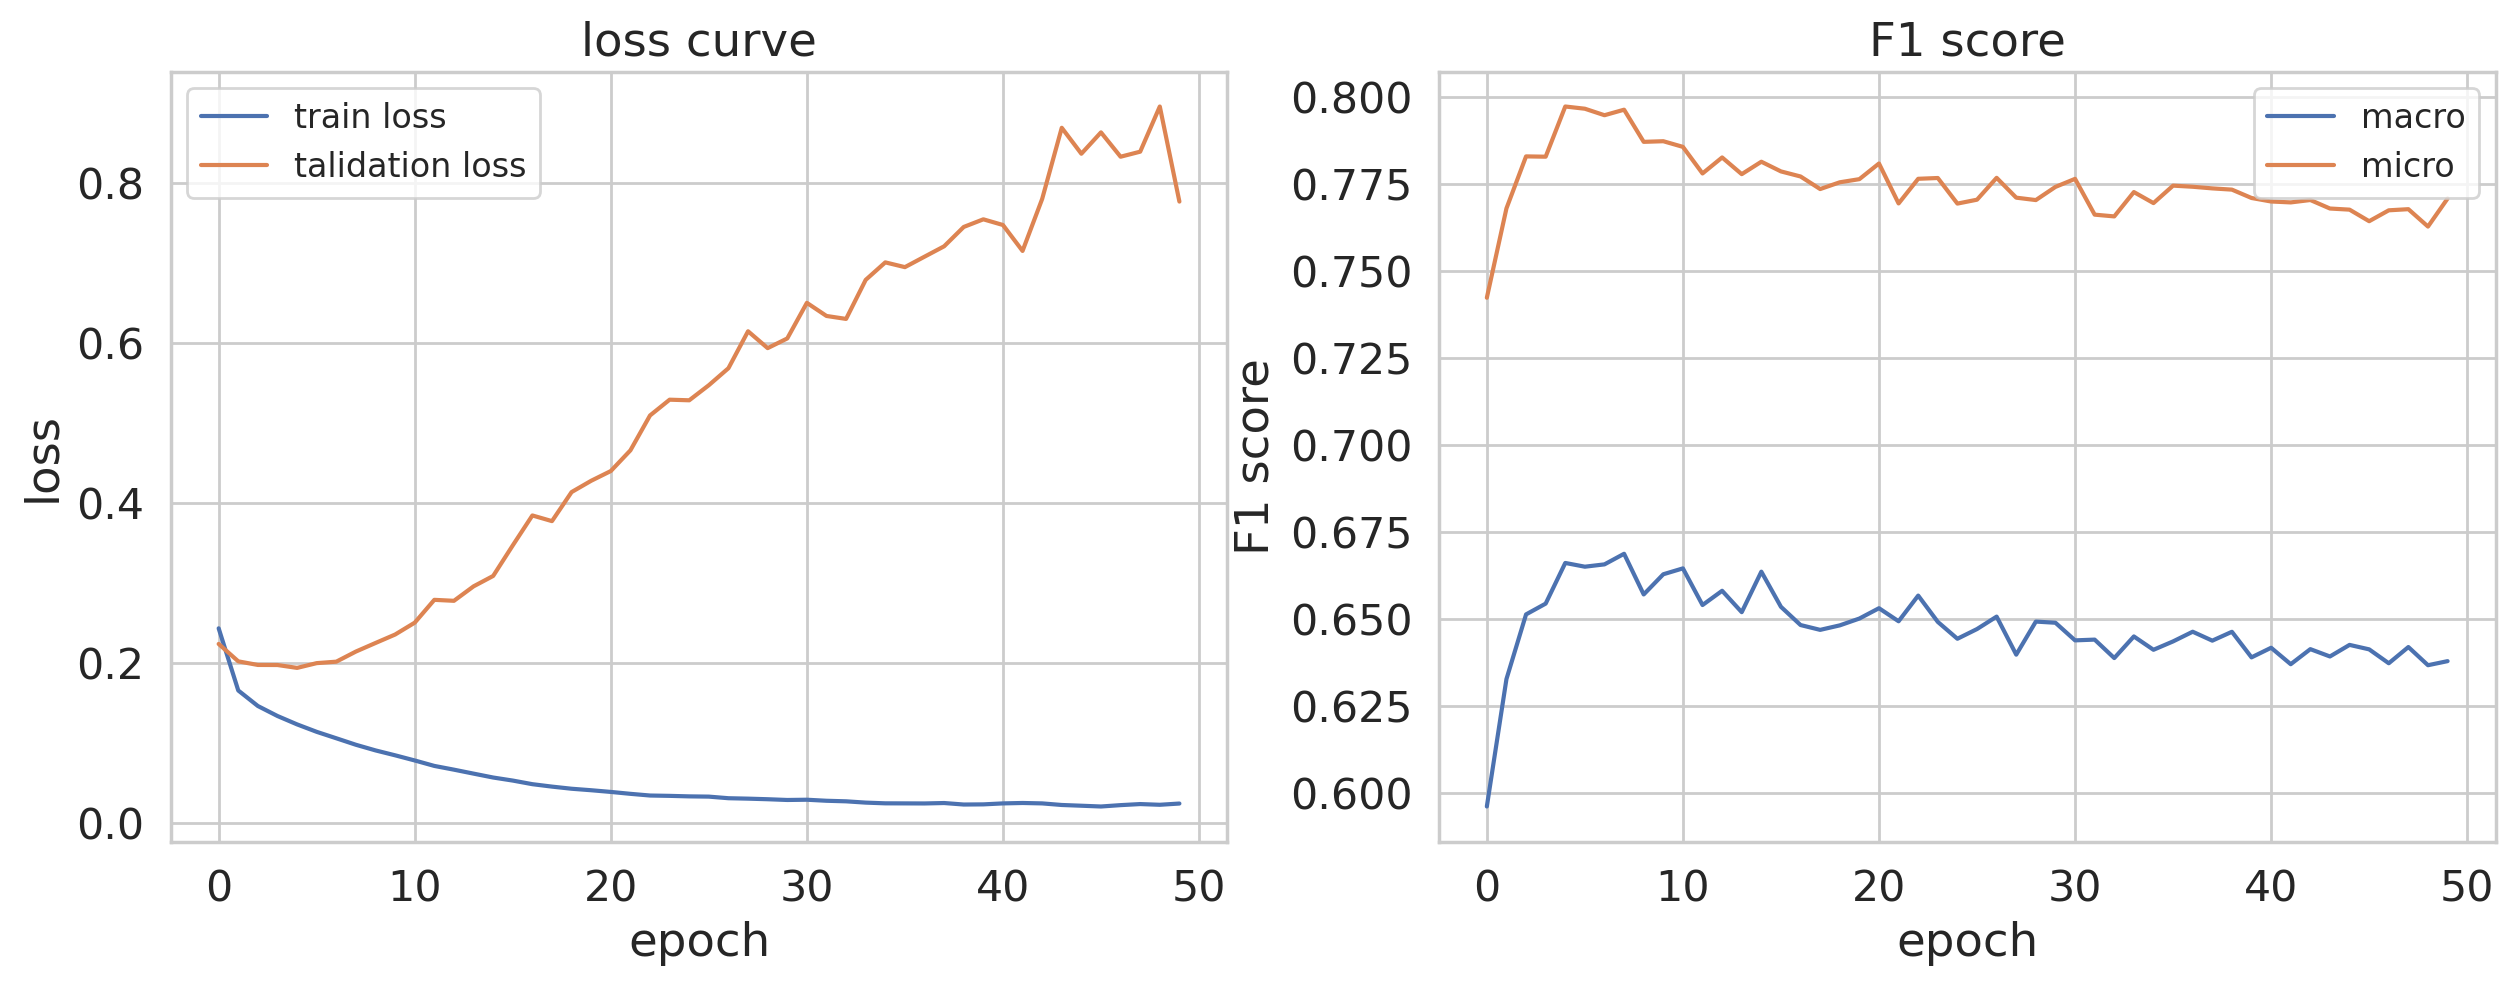

Using {'hidden_dims': [512, 256], 'activation': 'Tanh'}
epoch 0 time 1s train loss: 0.2361 valid loss: 0.2141 valid F1-micro: 0.75 valid F1-macro: 0.58
epoch 1 time 1s train loss: 0.1657 valid loss: 0.1959 valid F1-micro: 0.77 valid F1-macro: 0.63
epoch 2 time 1s train loss: 0.1482 valid loss: 0.1945 valid F1-micro: 0.78 valid F1-macro: 0.65
epoch 3 time 1s train loss: 0.1371 valid loss: 0.1950 valid F1-micro: 0.78 valid F1-macro: 0.66
epoch 4 time 1s train loss: 0.1285 valid loss: 0.1937 valid F1-micro: 0.78 valid F1-macro: 0.66
epoch 5 time 2s train loss: 0.1217 valid loss: 0.1945 valid F1-micro: 0.79 valid F1-macro: 0.67
epoch 6 time 1s train loss: 0.1154 valid loss: 0.1987 valid F1-micro: 0.79 valid F1-macro: 0.66
epoch 7 time 1s train loss: 0.1095 valid loss: 0.2028 valid F1-micro: 0.79 valid F1-macro: 0.66
epoch 8 time 1s train loss: 0.1042 valid loss: 0.2014 valid F1-micro: 0.79 valid F1-macro: 0.67
epoch 9 time 1s train loss: 0.0993 valid loss: 0.2012 valid F1-micro: 0.79 valid

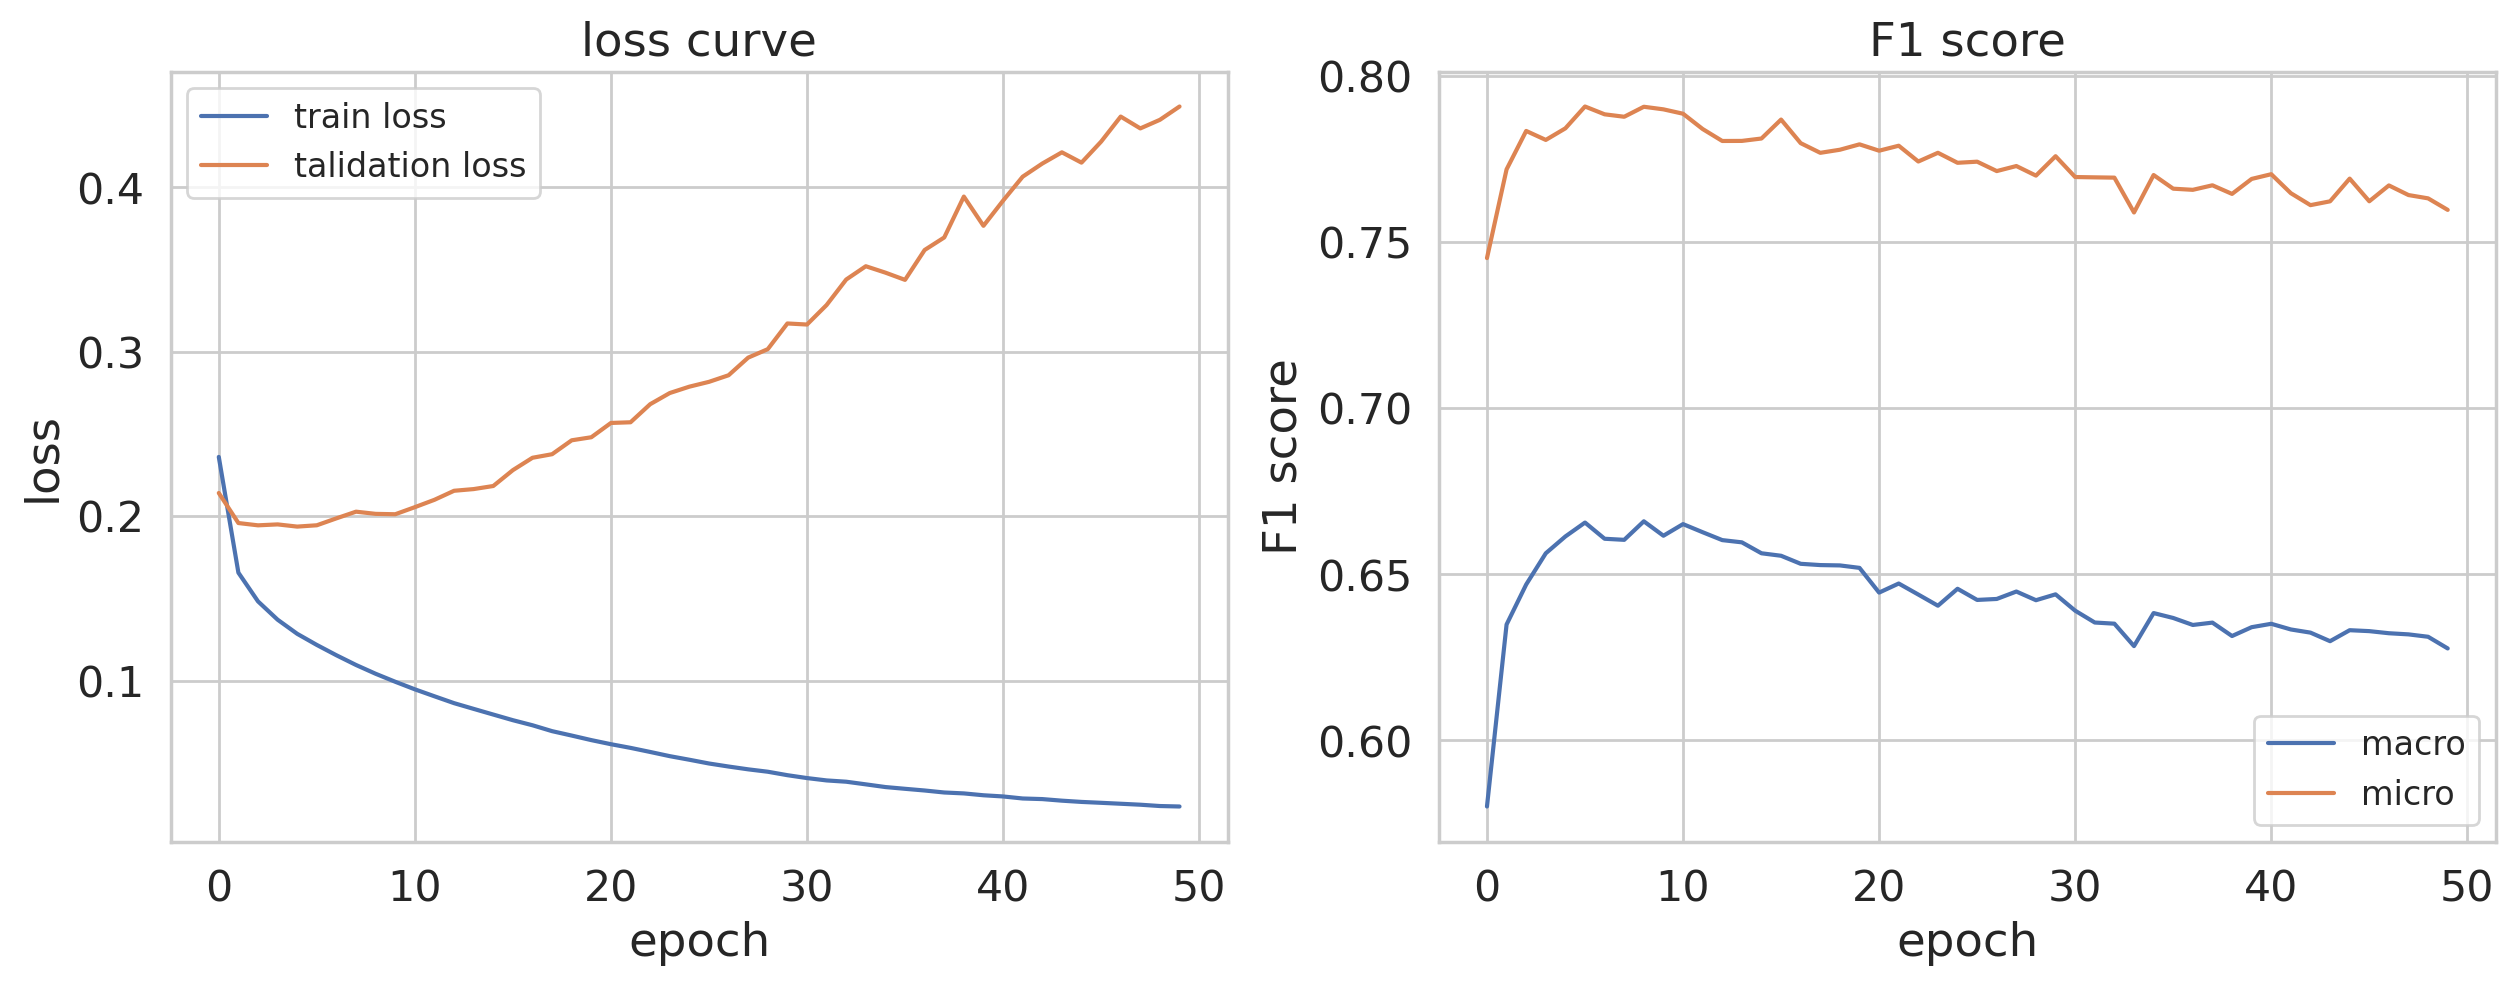

In [26]:
experiments = [
    {"hidden_dims": [512], "activation": "ReLU"},
    {"hidden_dims": [512, 256], "activation": "ReLU"},
    {"hidden_dims": [1024, 512, 256], "activation": "LeakyReLU"},
    {"hidden_dims": [512, 256], "activation": "Tanh"},
]

results = []
best_models = []

for config in experiments:
    print(f"Using {config}")

    model = TestModel(
        X_train_vec.shape[1],
        y_train.shape[1],
        hidden_dims=config["hidden_dims"],
        activation=config["activation"],
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    best_models.append(
        exper(50, model, train_dataloader, valid_dataloader, test_dataloader)
    )

Проведем тот-же эксперимент но с BERT векторизатором

In [27]:
X_train_BERT_vec = np.load("X_train_bert.npy")
X_valid_BERT_vec = np.load("X_valid_bert.npy")
X_test_BERT_vec = np.load("X_test_bert.npy")

In [ ]:
print(X_train_BERT_vec[2])

[-8.59873176e-01 -1.85403764e-01  1.65222481e-01 -9.98416066e-01
 -5.72767675e-01  6.67876601e-01 -3.20336252e-01 -1.18058395e+00
 -5.50011814e-01 -9.12494957e-02  9.87367034e-02  5.53376615e-01
  3.93378109e-01  2.53794730e-01  5.73752820e-02 -1.18198013e+00
  3.11057508e-01 -2.45463461e-01 -5.43152571e-01  4.88369912e-01
  2.34058395e-01  3.18983883e-01 -7.27684498e-02 -2.54478961e-01
  7.07828522e-01  4.13823396e-01 -1.41582191e-01 -4.97759134e-02
  5.72941080e-03 -4.97134924e-01 -4.19889867e-01  8.81249011e-02
  2.52450347e-01  4.65320140e-01 -2.35462964e-01  5.79566956e-01
  2.35610887e-01 -2.97154009e-01  6.34762883e-01 -2.05071554e-01
 -4.87666488e-01 -2.51275059e-02  9.17504489e-01  3.82634044e-01
  2.40214672e-02  4.33023244e-01 -1.15115188e-01 -2.26638854e-01
 -4.64166939e-01 -6.44383729e-01  5.87165952e-02 -8.41854572e-01
  3.00735652e-01  1.72851458e-01 -2.88839668e-01  7.86107033e-02
  3.48918736e-01  2.65956223e-01  6.28735125e-01  7.89841235e-01
 -1.26553029e-02  9.79214

In [28]:
train_dataset = TextDataset(X_train_BERT_vec, y_train)
valid_dataset = TextDataset(X_valid_BERT_vec, y_valid)
test_dataset = TextDataset(X_test_BERT_vec, y_test)

batch_size = 256
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Using {'hidden_dims': [512], 'activation': 'ReLU'}
epoch 0 time 4s train loss: 0.2960 valid loss: 0.2893 valid F1-micro: 0.64 valid F1-macro: 0.46
epoch 1 time 2s train loss: 0.2369 valid loss: 0.2595 valid F1-micro: 0.68 valid F1-macro: 0.52
epoch 2 time 2s train loss: 0.2208 valid loss: 0.2496 valid F1-micro: 0.70 valid F1-macro: 0.55
epoch 3 time 1s train loss: 0.2111 valid loss: 0.2429 valid F1-micro: 0.71 valid F1-macro: 0.57
epoch 4 time 1s train loss: 0.2042 valid loss: 0.2347 valid F1-micro: 0.73 valid F1-macro: 0.58
epoch 5 time 1s train loss: 0.1988 valid loss: 0.2281 valid F1-micro: 0.74 valid F1-macro: 0.59
epoch 6 time 2s train loss: 0.1942 valid loss: 0.2275 valid F1-micro: 0.74 valid F1-macro: 0.59
epoch 7 time 1s train loss: 0.1908 valid loss: 0.2214 valid F1-micro: 0.74 valid F1-macro: 0.60
epoch 8 time 1s train loss: 0.1875 valid loss: 0.2209 valid F1-micro: 0.74 valid F1-macro: 0.60
epoch 9 time 1s train loss: 0.1845 valid loss: 0.2218 valid F1-micro: 0.75 valid F1-m

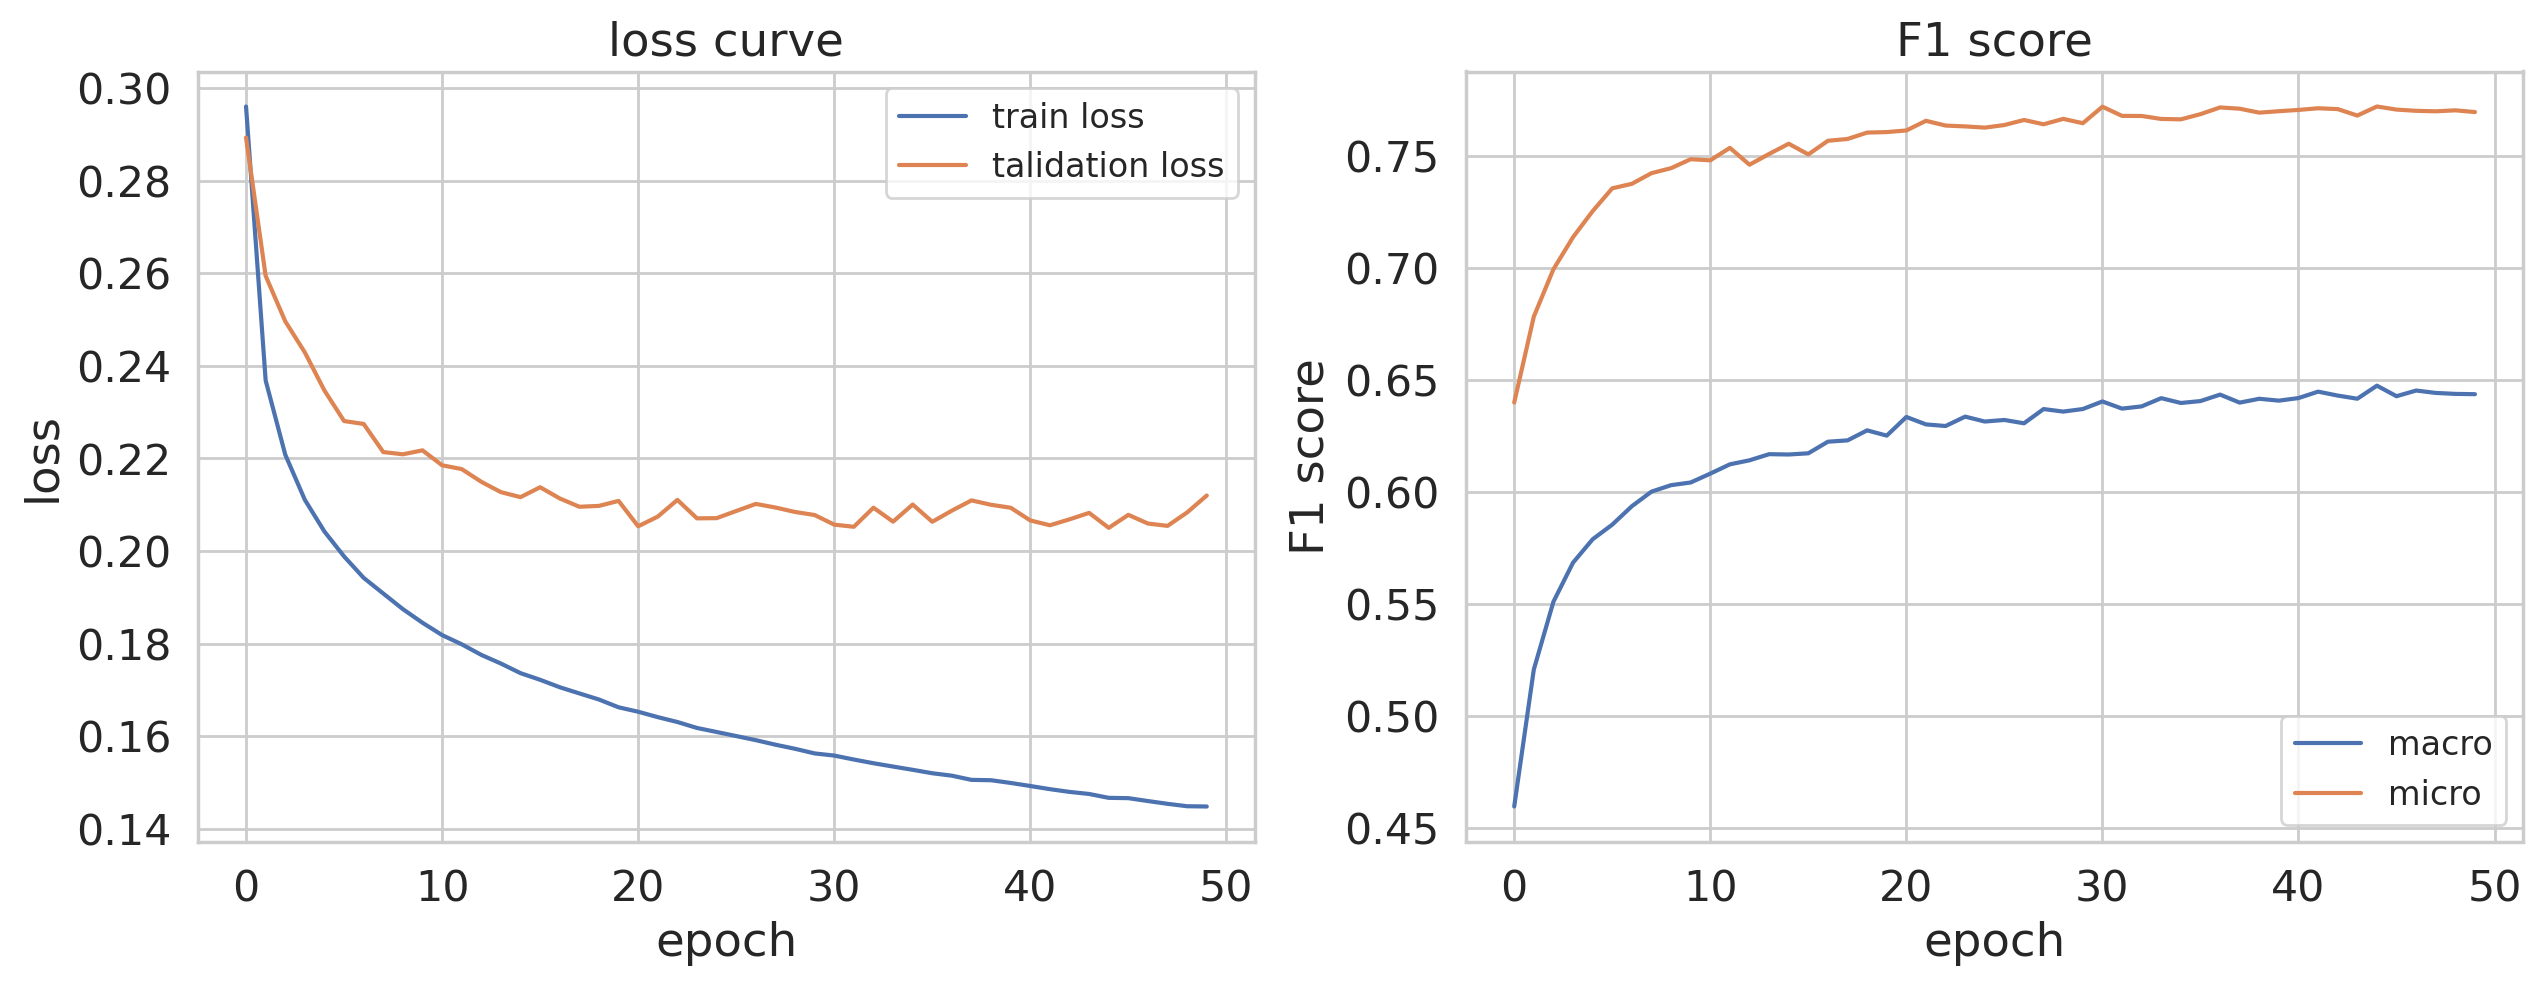

Using {'hidden_dims': [512, 256], 'activation': 'ReLU'}
epoch 0 time 1s train loss: 0.3017 valid loss: 0.2908 valid F1-micro: 0.63 valid F1-macro: 0.45
epoch 1 time 1s train loss: 0.2334 valid loss: 0.2583 valid F1-micro: 0.68 valid F1-macro: 0.53
epoch 2 time 1s train loss: 0.2152 valid loss: 0.2399 valid F1-micro: 0.72 valid F1-macro: 0.56
epoch 3 time 1s train loss: 0.2037 valid loss: 0.2303 valid F1-micro: 0.73 valid F1-macro: 0.58
epoch 4 time 2s train loss: 0.1955 valid loss: 0.2233 valid F1-micro: 0.74 valid F1-macro: 0.59
epoch 5 time 1s train loss: 0.1897 valid loss: 0.2234 valid F1-micro: 0.74 valid F1-macro: 0.60
epoch 6 time 1s train loss: 0.1847 valid loss: 0.2182 valid F1-micro: 0.75 valid F1-macro: 0.60
epoch 7 time 1s train loss: 0.1807 valid loss: 0.2134 valid F1-micro: 0.75 valid F1-macro: 0.61
epoch 8 time 1s train loss: 0.1776 valid loss: 0.2127 valid F1-micro: 0.75 valid F1-macro: 0.61
epoch 9 time 1s train loss: 0.1742 valid loss: 0.2140 valid F1-micro: 0.75 valid

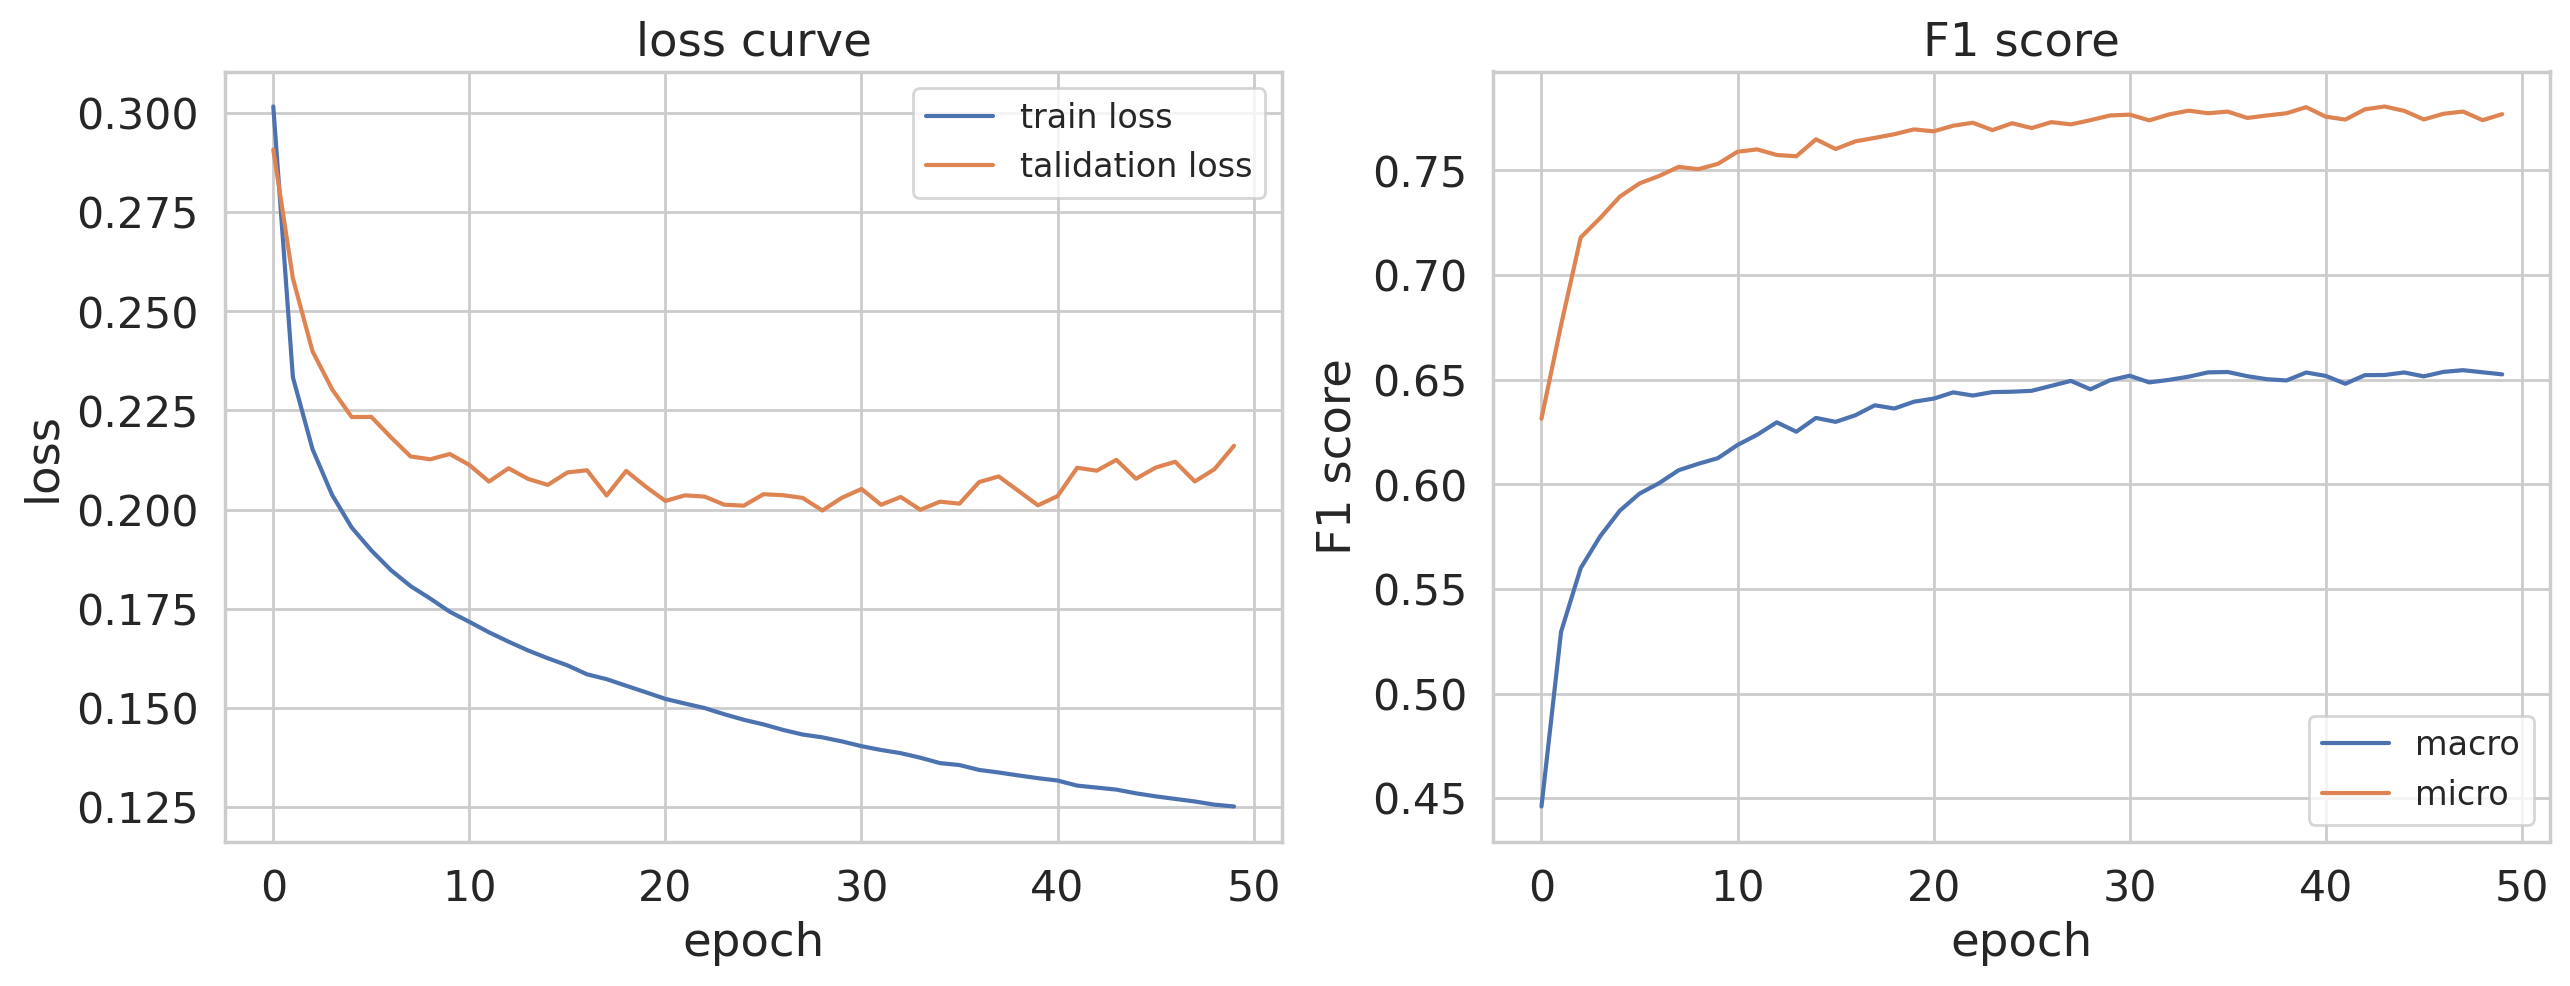

Using {'hidden_dims': [1024, 512, 256], 'activation': 'LeakyReLU'}
epoch 0 time 2s train loss: 0.2858 valid loss: 0.2593 valid F1-micro: 0.68 valid F1-macro: 0.53
epoch 1 time 1s train loss: 0.2127 valid loss: 0.2284 valid F1-micro: 0.73 valid F1-macro: 0.57
epoch 2 time 1s train loss: 0.1931 valid loss: 0.2230 valid F1-micro: 0.74 valid F1-macro: 0.59
epoch 3 time 1s train loss: 0.1813 valid loss: 0.2098 valid F1-micro: 0.76 valid F1-macro: 0.61
epoch 4 time 1s train loss: 0.1730 valid loss: 0.2079 valid F1-micro: 0.76 valid F1-macro: 0.61
epoch 5 time 1s train loss: 0.1672 valid loss: 0.2074 valid F1-micro: 0.76 valid F1-macro: 0.62
epoch 6 time 1s train loss: 0.1615 valid loss: 0.2025 valid F1-micro: 0.76 valid F1-macro: 0.63
epoch 7 time 1s train loss: 0.1571 valid loss: 0.2108 valid F1-micro: 0.76 valid F1-macro: 0.63
epoch 8 time 2s train loss: 0.1530 valid loss: 0.2008 valid F1-micro: 0.77 valid F1-macro: 0.64
epoch 9 time 1s train loss: 0.1489 valid loss: 0.2052 valid F1-micro:

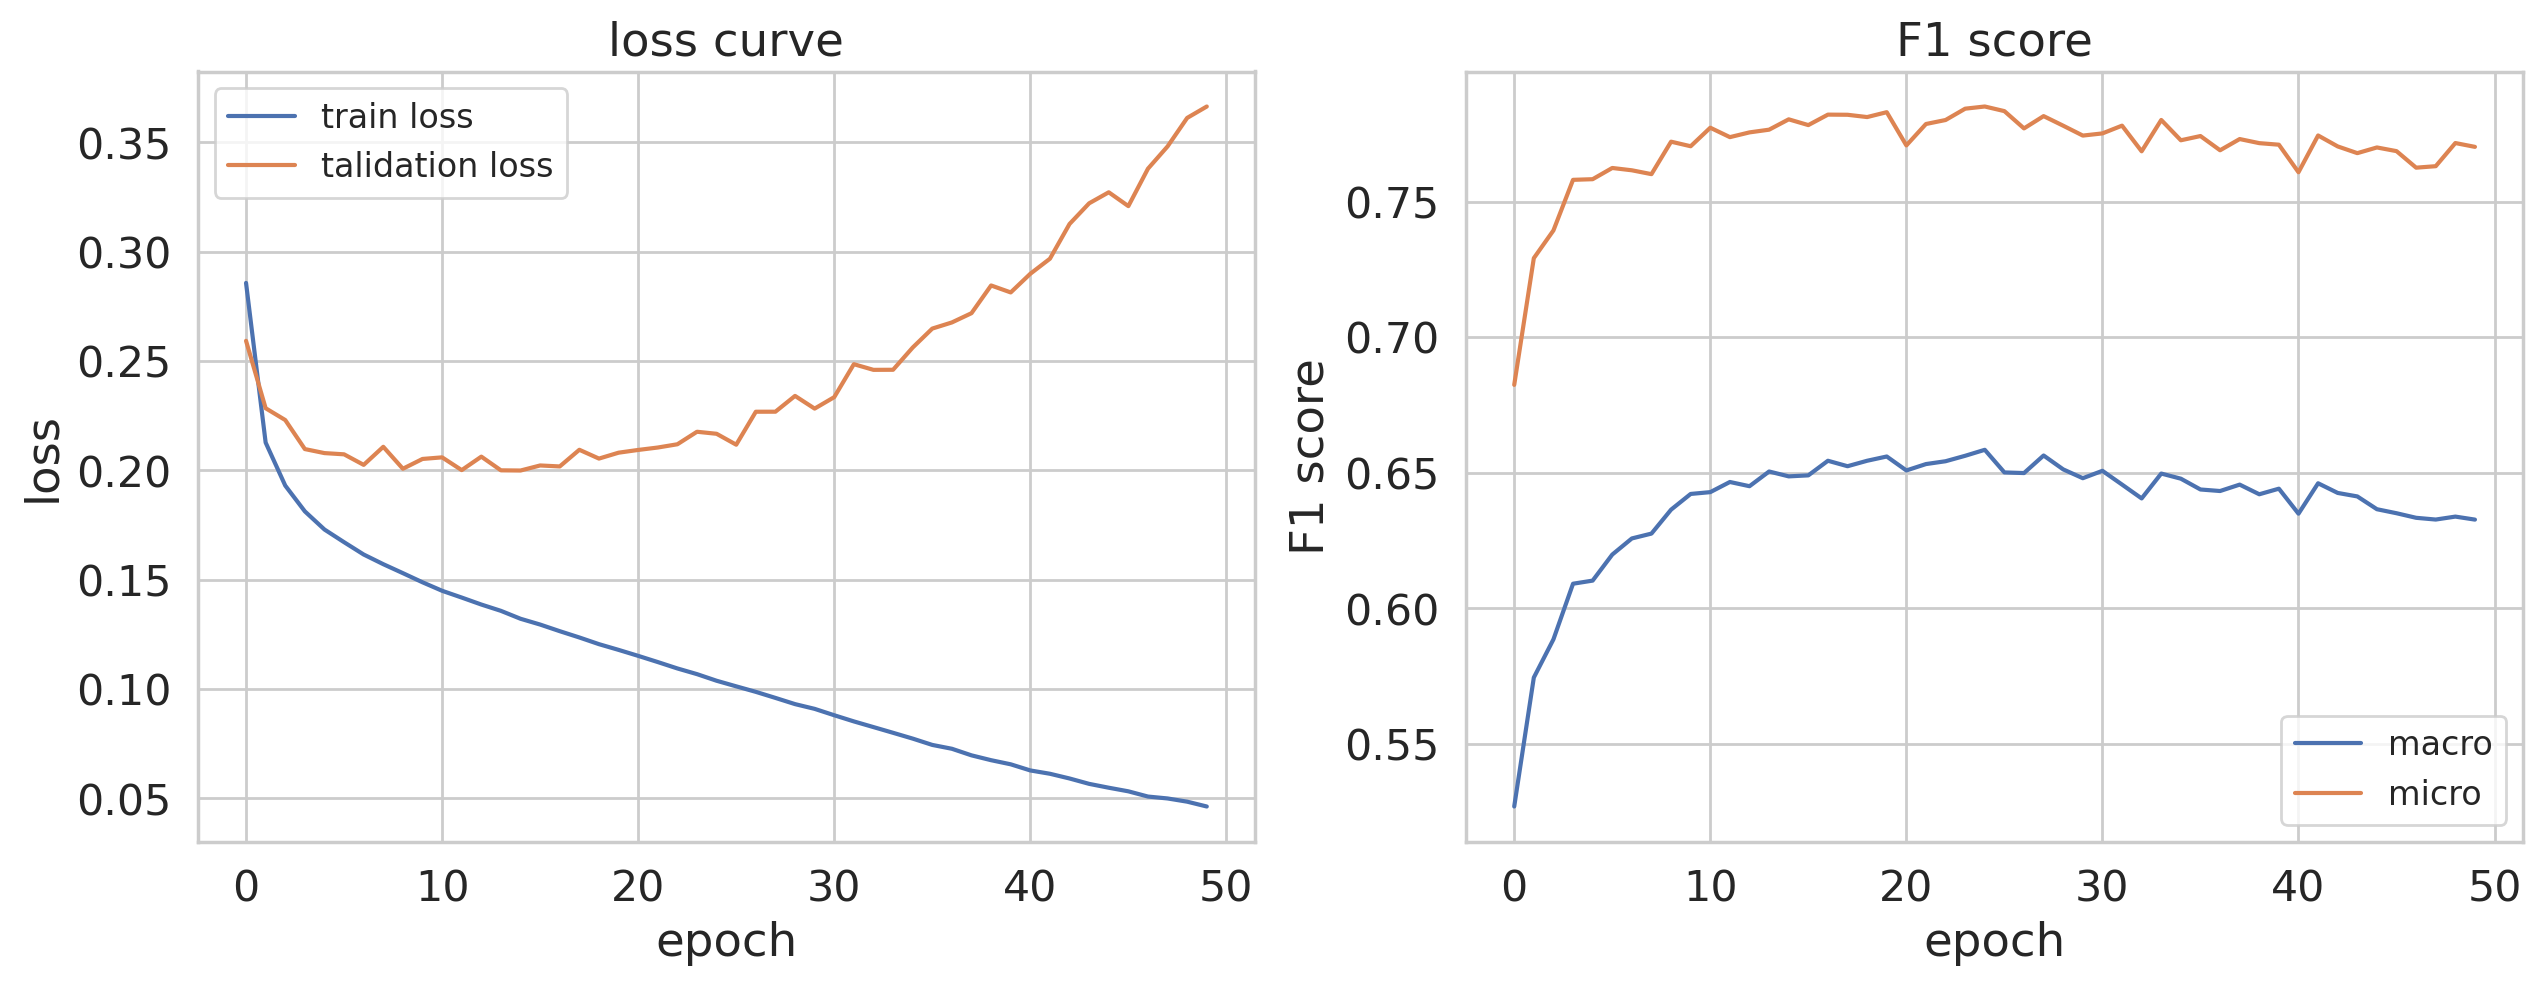

Using {'hidden_dims': [512, 256], 'activation': 'Tanh'}
epoch 0 time 1s train loss: 0.3026 valid loss: 0.2932 valid F1-micro: 0.62 valid F1-macro: 0.44
epoch 1 time 2s train loss: 0.2345 valid loss: 0.2532 valid F1-micro: 0.69 valid F1-macro: 0.53
epoch 2 time 2s train loss: 0.2112 valid loss: 0.2317 valid F1-micro: 0.72 valid F1-macro: 0.56
epoch 3 time 1s train loss: 0.1985 valid loss: 0.2234 valid F1-micro: 0.74 valid F1-macro: 0.59
epoch 4 time 1s train loss: 0.1904 valid loss: 0.2205 valid F1-micro: 0.74 valid F1-macro: 0.60
epoch 5 time 1s train loss: 0.1846 valid loss: 0.2130 valid F1-micro: 0.76 valid F1-macro: 0.60
epoch 6 time 1s train loss: 0.1799 valid loss: 0.2138 valid F1-micro: 0.75 valid F1-macro: 0.60
epoch 7 time 1s train loss: 0.1759 valid loss: 0.2102 valid F1-micro: 0.76 valid F1-macro: 0.61
epoch 8 time 1s train loss: 0.1727 valid loss: 0.2101 valid F1-micro: 0.76 valid F1-macro: 0.61
epoch 9 time 1s train loss: 0.1697 valid loss: 0.2068 valid F1-micro: 0.76 valid

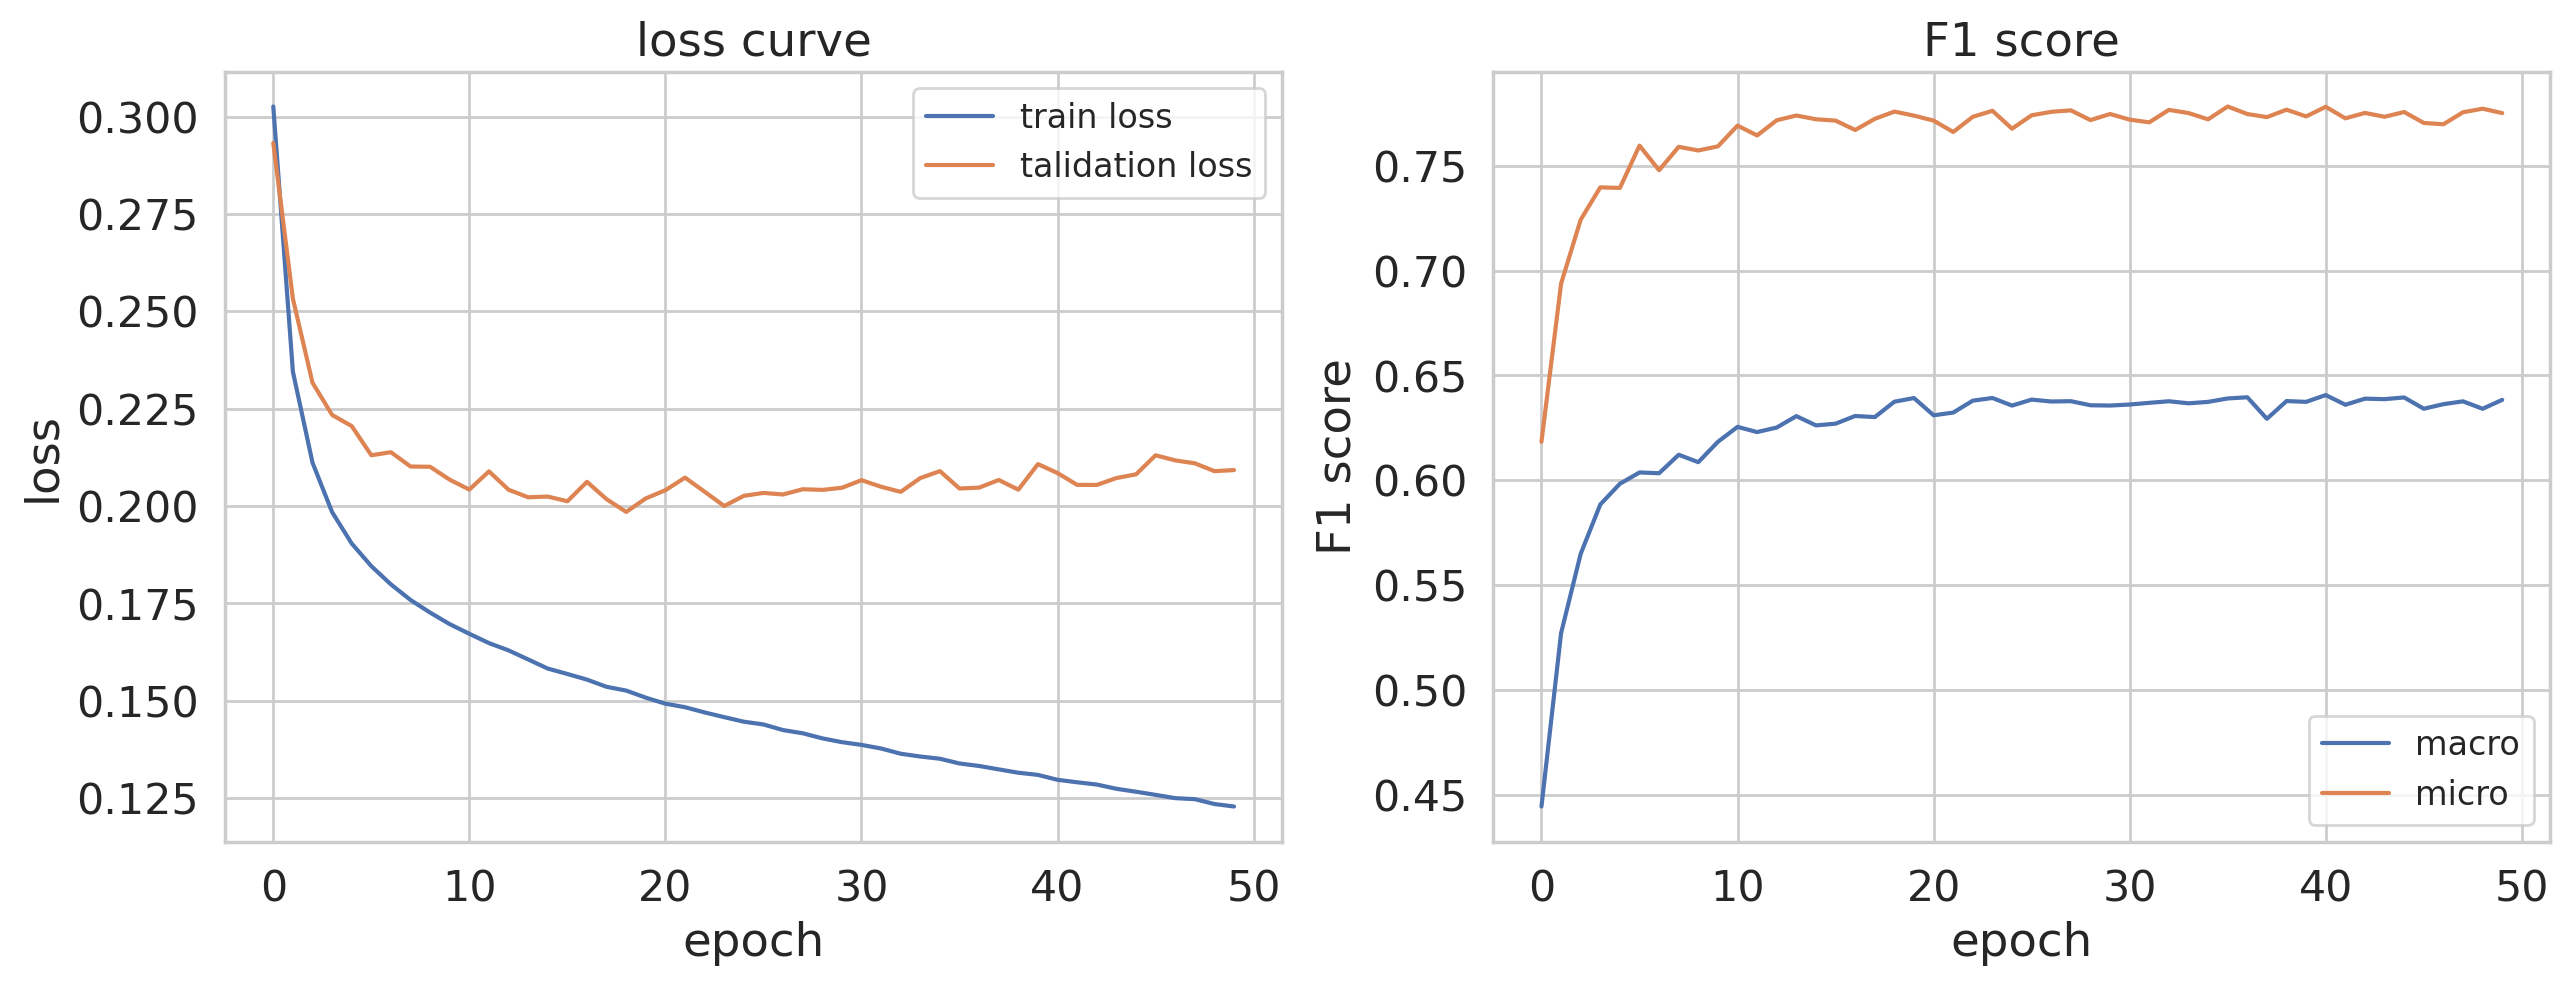

In [30]:
experiments = [
    {"hidden_dims": [512], "activation": "ReLU"},
    {"hidden_dims": [512, 256], "activation": "ReLU"},
    {"hidden_dims": [1024, 512, 256], "activation": "LeakyReLU"},
    {"hidden_dims": [512, 256], "activation": "Tanh"},
]

results = []
best_models = []

for config in experiments:
    print(f"Using {config}")

    model = TestModel(
        X_train_BERT_vec.shape[1],
        y_train.shape[1],
        hidden_dims=config["hidden_dims"],
        activation=config["activation"],
    ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    best_models.append(
        exper(50, model, train_dataloader, valid_dataloader, test_dataloader)
    )

Первое, что сразу можно подметить, это то, что модель использующая coutvectorizer начинает переобучаться довольно быстро. Также при использовании более глубокой модели модель с BERT векторизацией также бысро переобучилась. Показатели всех моделей не сильно отличаются, однако, модели использующие BERT векторизаторизатор, имеют более стабильные показатели

__Дополнительное задание (10 баллов):__ В экспериментах выше документ представляется в виде одного вектора. В задании предлагается разобраться с базовой теорией сверточных нейронных сетей самостоятельно и выполнить следующие пункты:

- заменить это представление на по-токенное (т.е. документ - матрица векторов, по одному на каждый токен)
- в качестве векторов попробовать использовать выходы BERT или обучить модель Word2vec/FastText
- предложить и реализовать способ организации процесса векторизации и обучения, чтобы избавиться от проблемы различной длины документов
- попробовать в качестве первого слоя в модели одномерный сверточный слой с Global Max Pooling или K-max Pooling поверх его выходов
- провести любые иные улучшения модели с использованием свёрточных слоёв, слоёв пулинга, линейных слоёв и нелинейных активаций
- задокументировать все эксперименты и попытаться получить результаты выше, чем у лучше модели из основной части задания